# House Prices - Advanced Regression Techniques 🏡
This project uses the House Prices dataset from [Kaggle](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)
to predict the house price for each house in the dataset. 

## Steps:
1. Import libraries
2. Import the datasets
3. Data Overview 
4. Exploratory data analysis (EDA)
5. Data preprocessing & cleaning
6. Feature engineering
7. Model training and Evaluation
8. Submission file (for Kaggle)

# 1. Import libraries

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2-Importing Datasets

In [166]:
train_df = pd.read_csv(r"C:\Users\maria\Downloads\house-prices-advanced-regression-techniques\train.csv")
test_df = pd.read_csv(r"C:\Users\maria\Downloads\house-prices-advanced-regression-techniques\test.csv")

# 3-Data Overview

In [167]:

print("Shape:", train_df.shape)

print("\nInfo:")
train_df.info()

print("\nSummary statistics (numeric):")
display(train_df.describe())

print("\nSummary statistics (categorical):")
display(train_df.describe(include='object'))

print("\nFirst 5 rows:")
display(train_df.head())

print("\nData types:")
print(train_df.dtypes.value_counts())

print("\nMissing values (top 20):")
print(train_df.isnull().sum().sort_values(ascending=False).head(20))

print("\nNumber of duplicate rows:", train_df.duplicated().sum())


Shape: (1460, 81)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nul

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Summary statistics (categorical):


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198



First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Data types:
object     43
int64      35
float64     3
Name: count, dtype: int64

Missing values (top 20):
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

Number of duplicate rows: 0


# 4-Exploratory data analysis (EDA)

1- Feature Distributions 

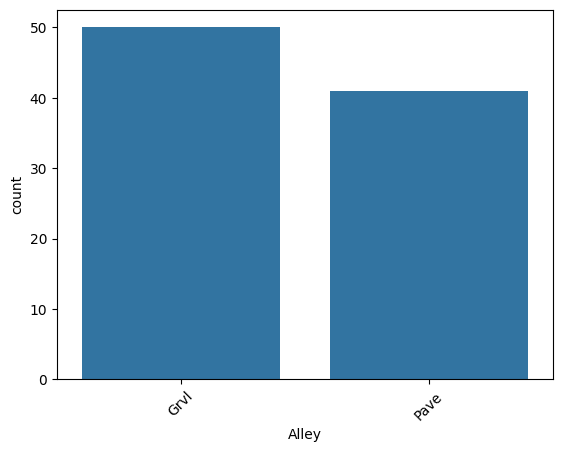

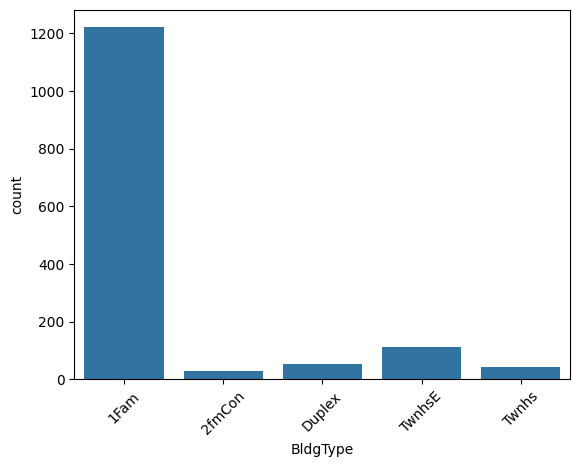

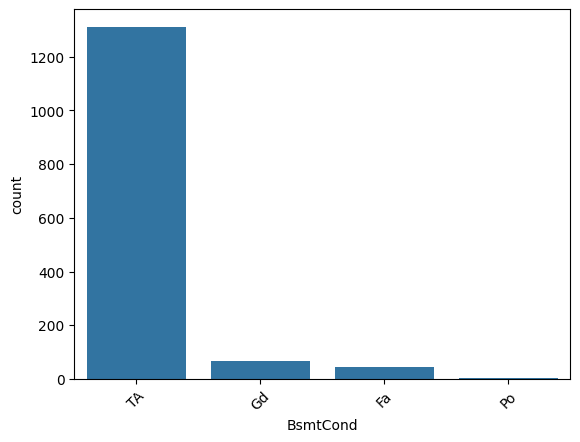

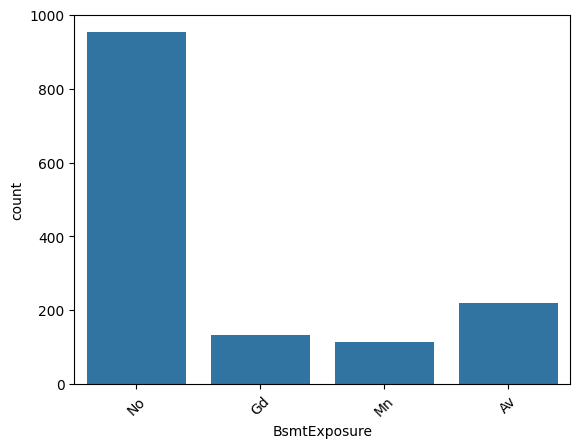

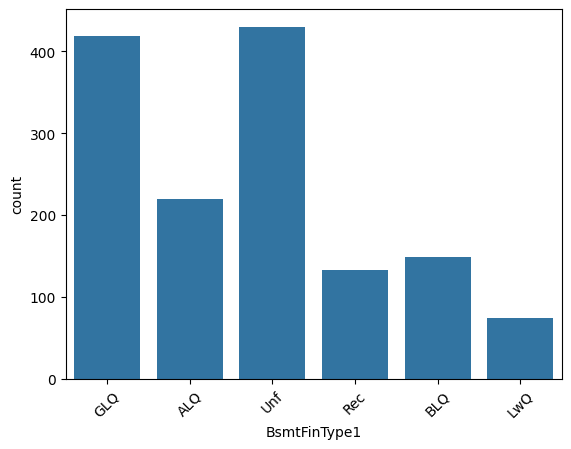

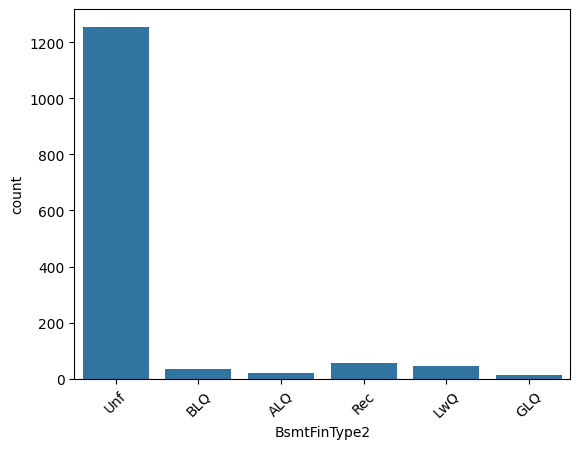

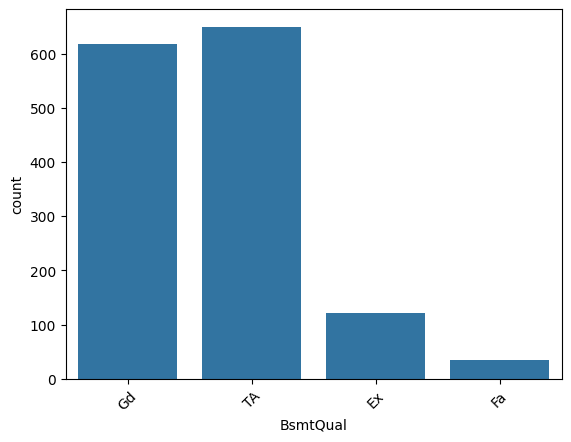

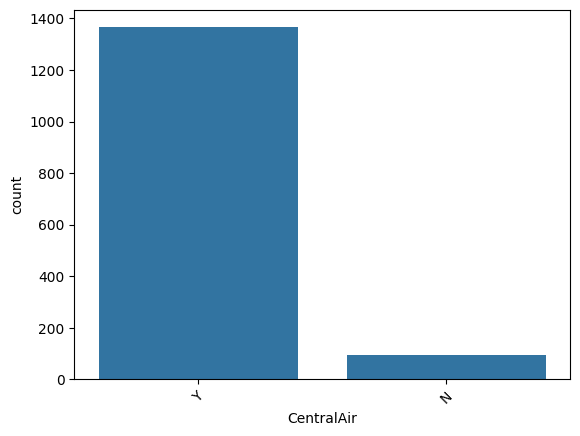

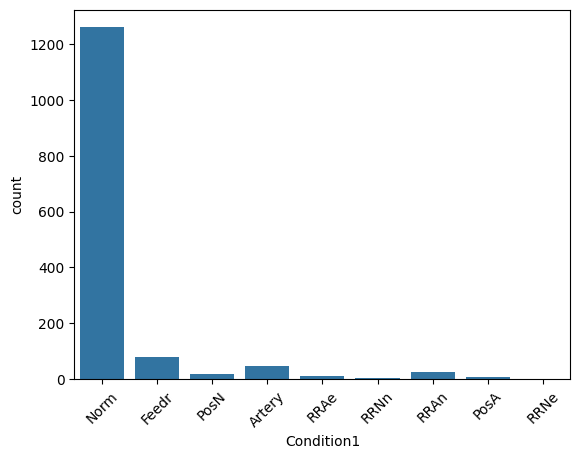

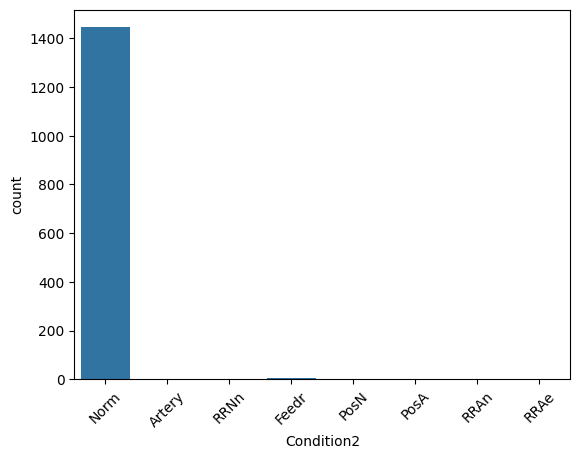

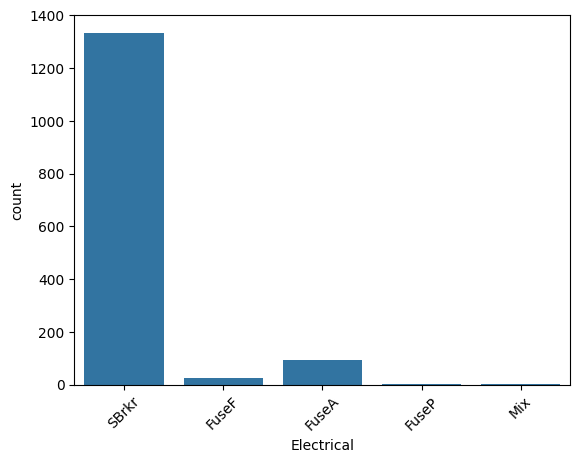

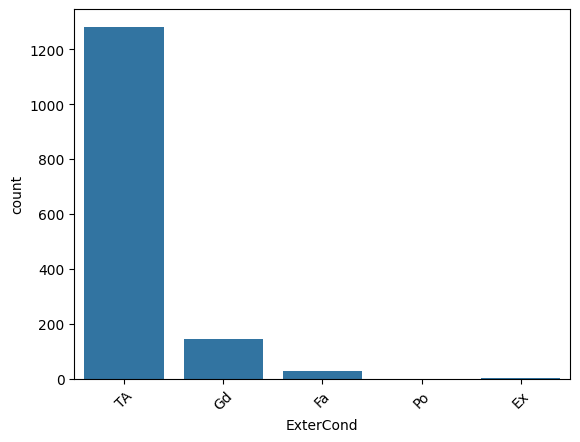

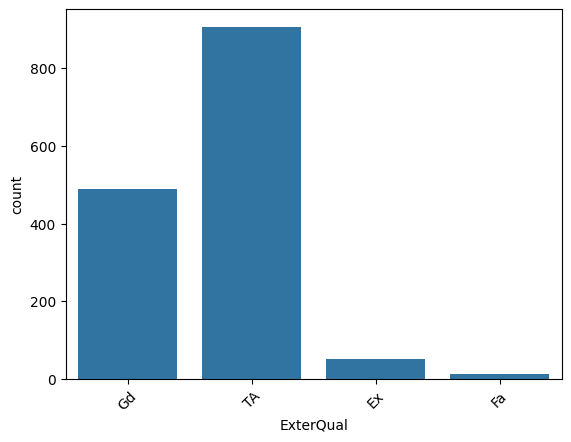

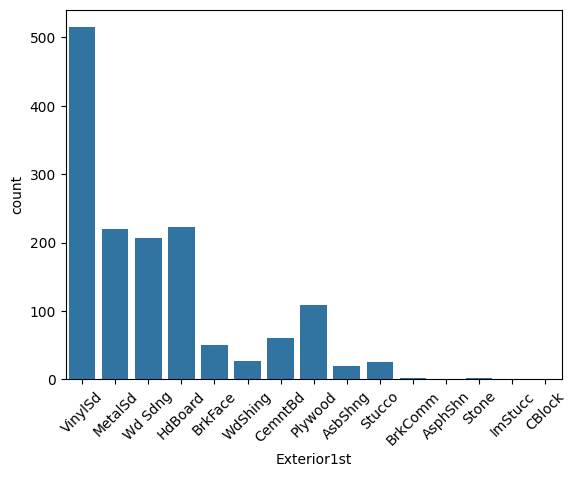

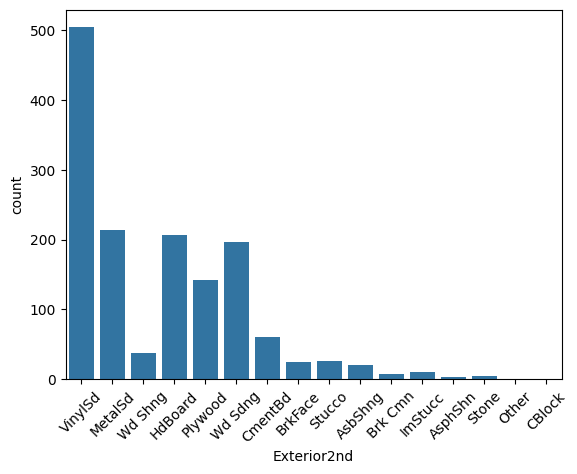

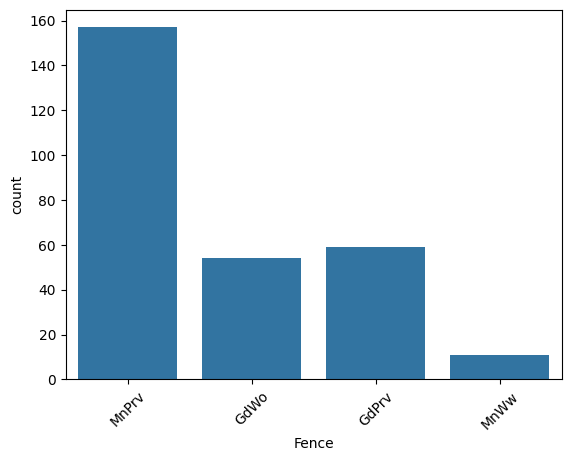

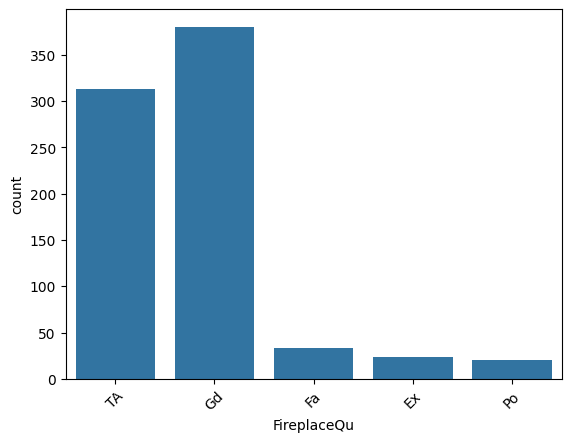

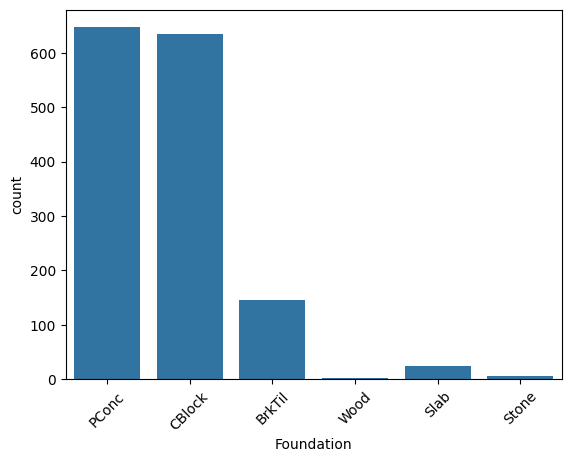

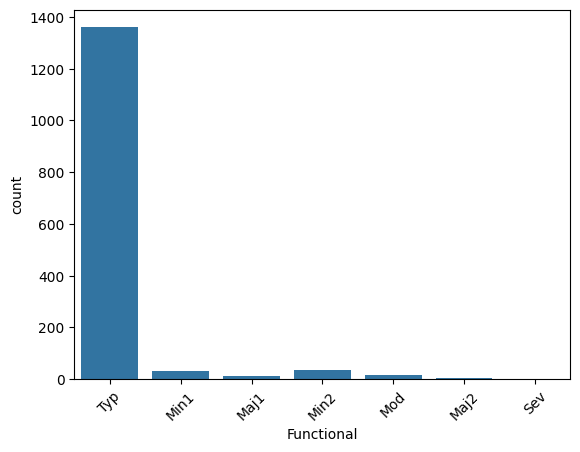

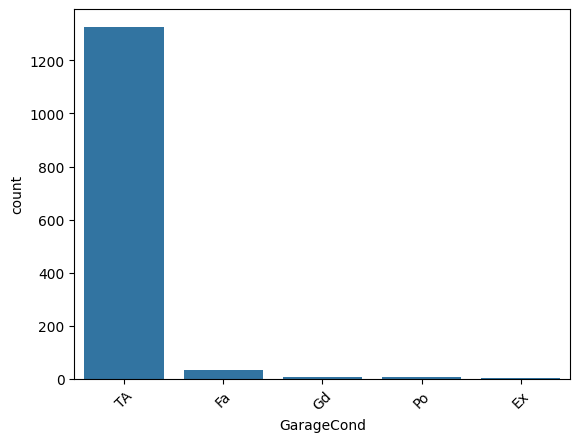

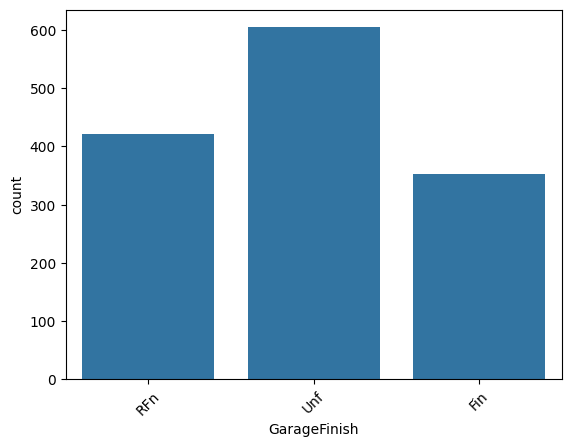

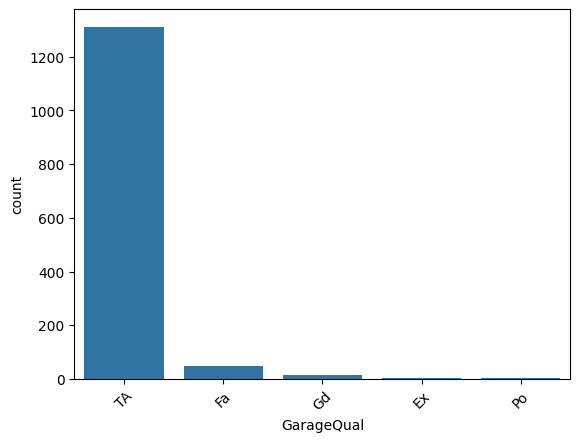

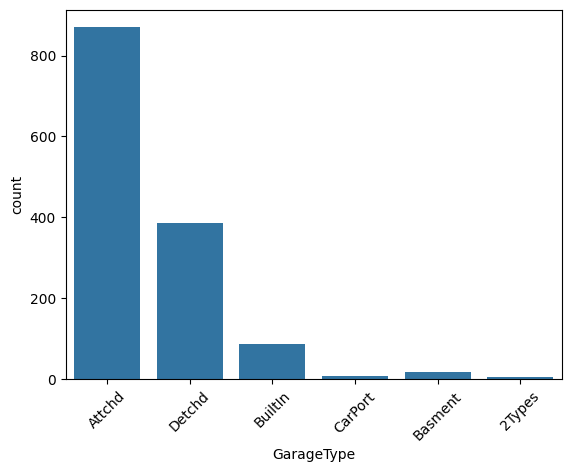

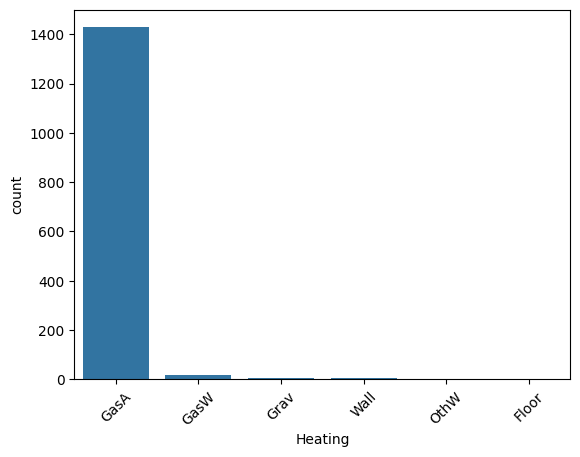

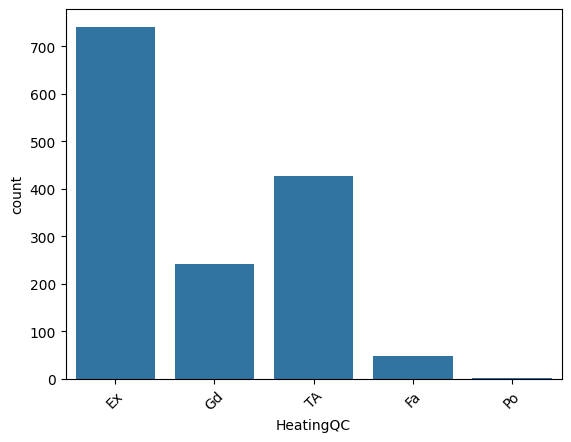

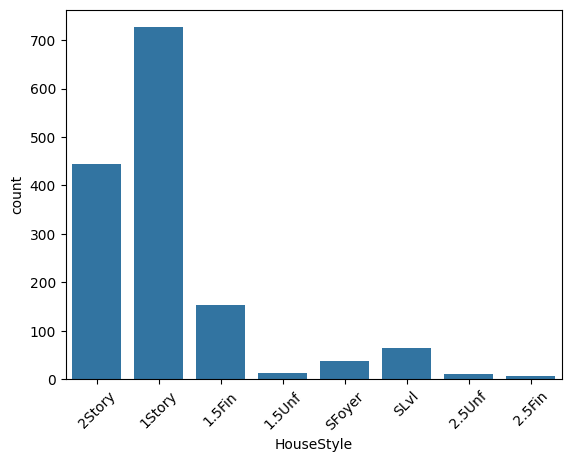

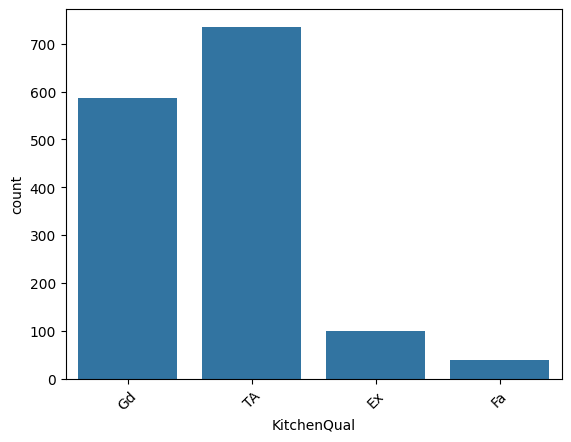

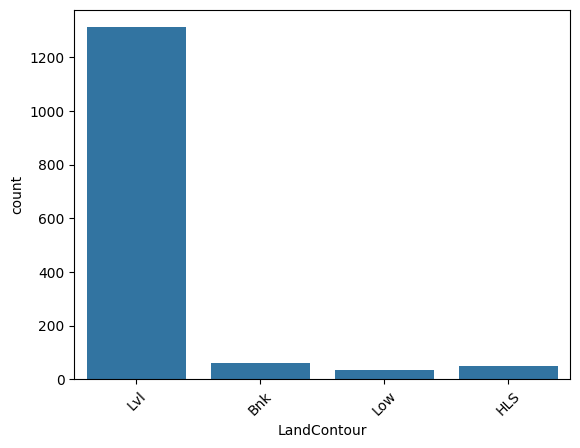

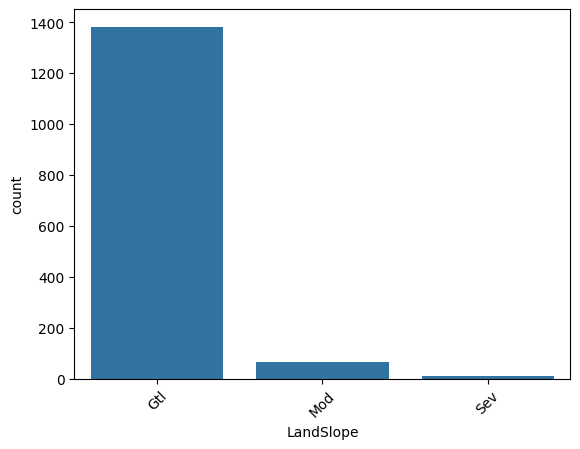

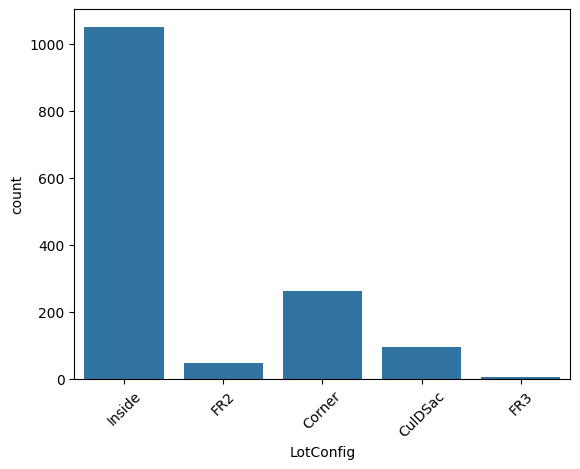

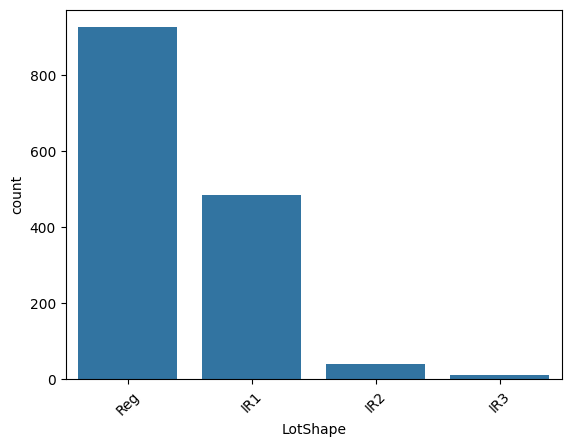

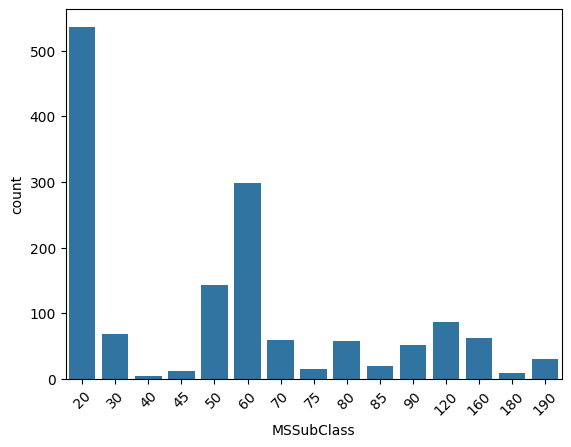

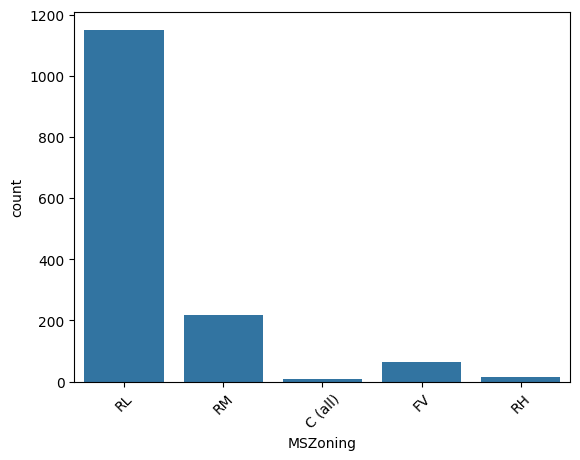

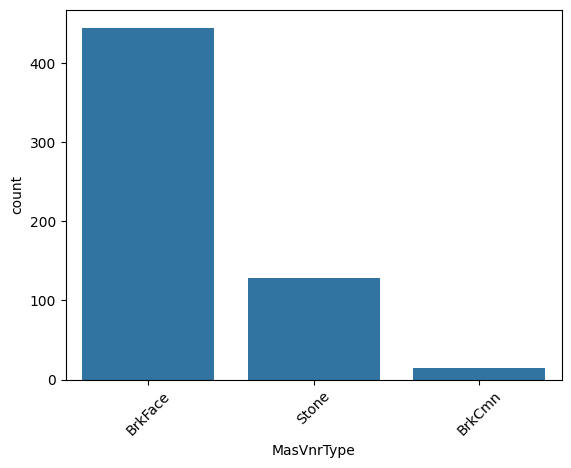

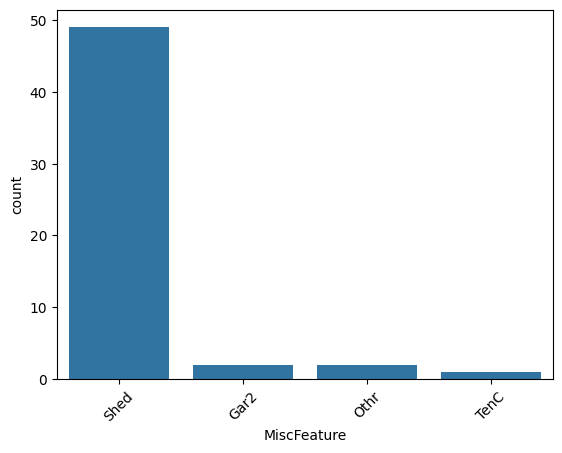

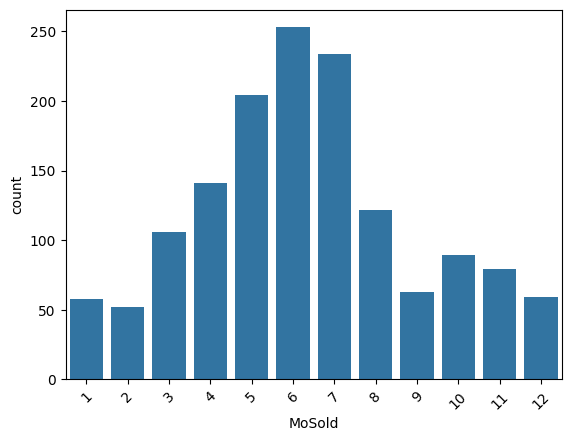

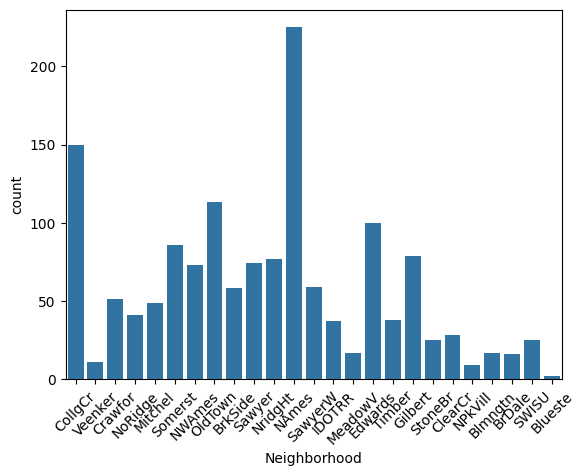

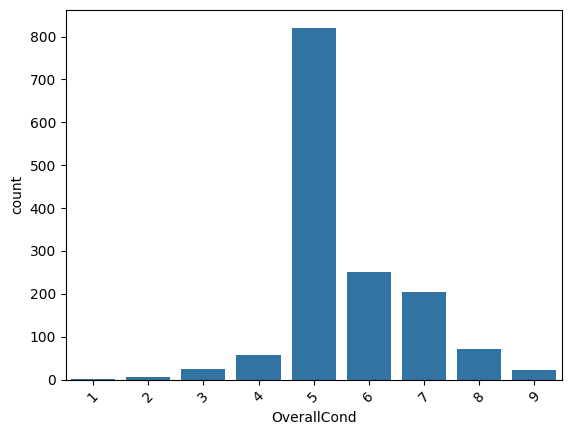

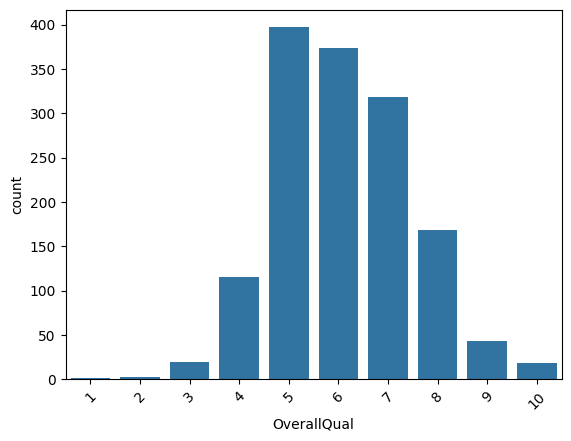

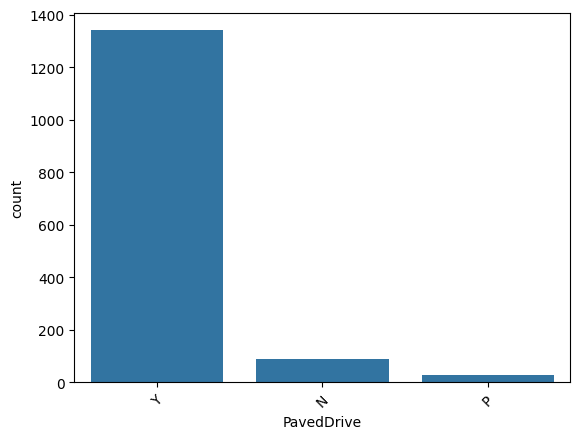

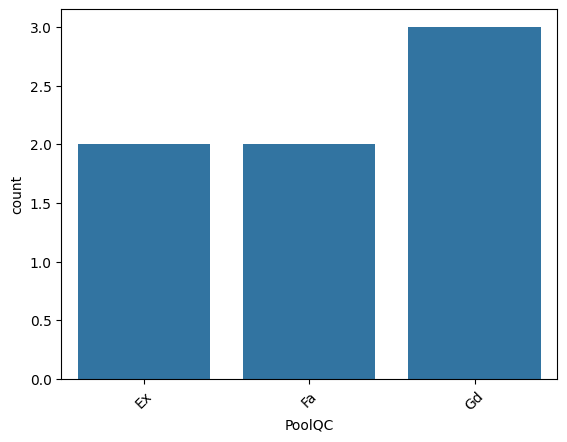

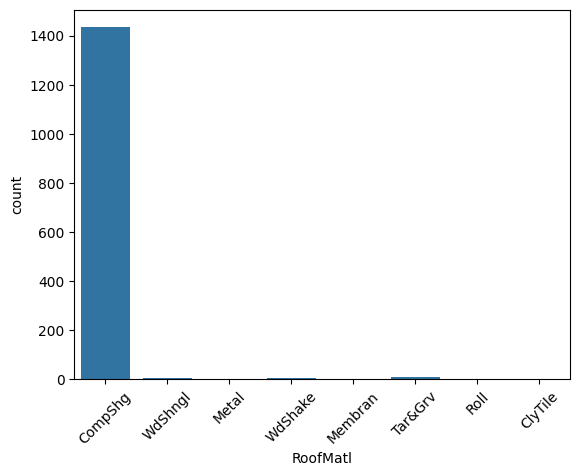

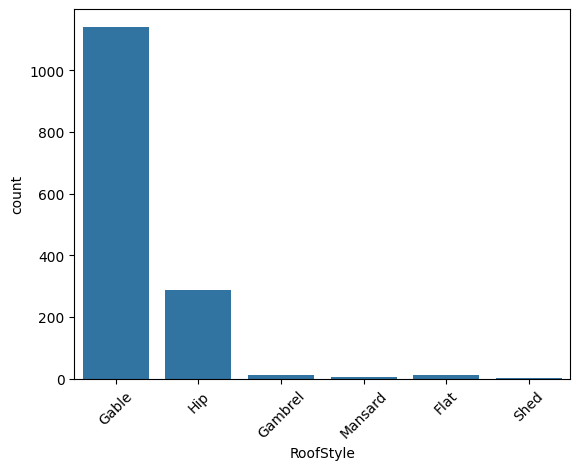

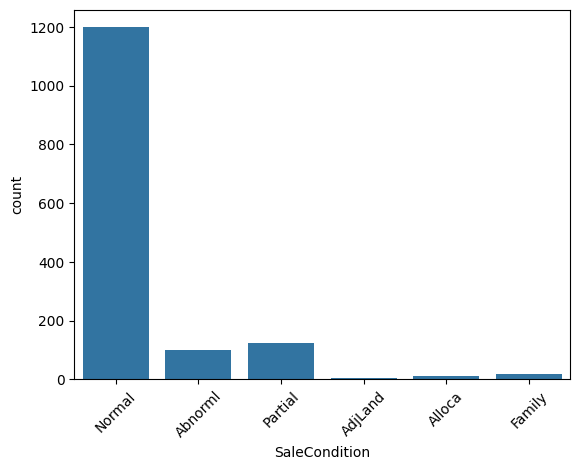

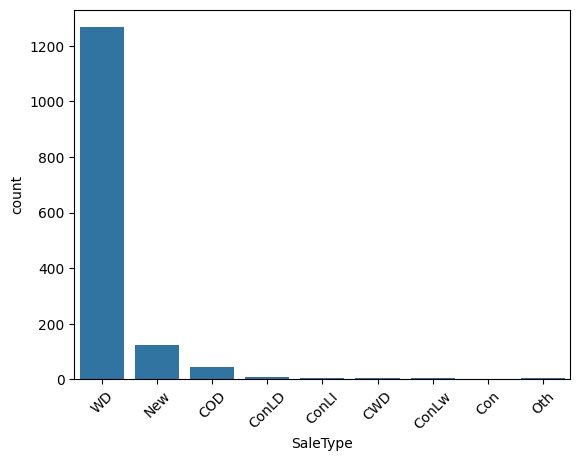

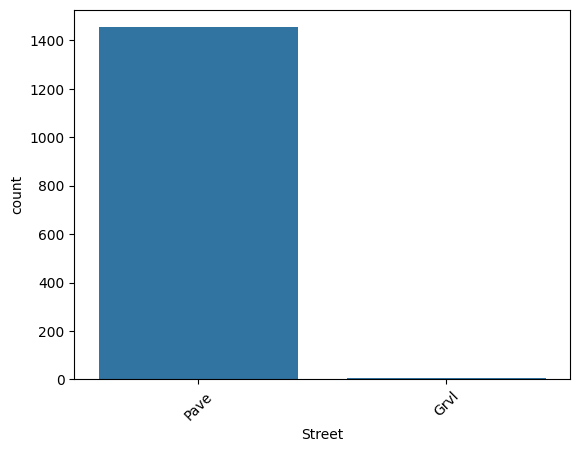

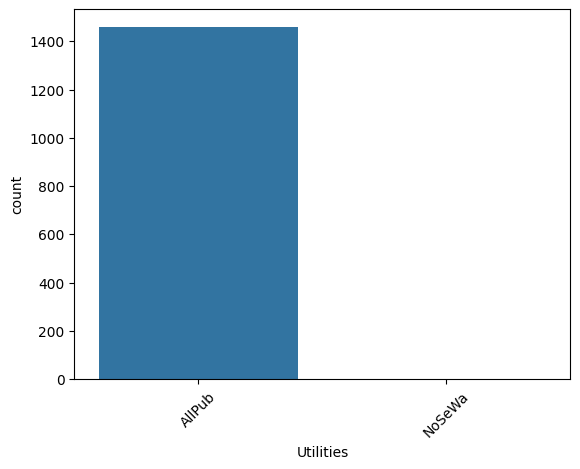

In [168]:
#Distribution of categorical columns

for column in train_df.select_dtypes(include = 'object').columns.union(['MSSubClass','OverallQual', 'OverallCond','MoSold']):
    sns.countplot(x=column, data=train_df)
    plt.xticks(rotation=45)
    plt.show()
    

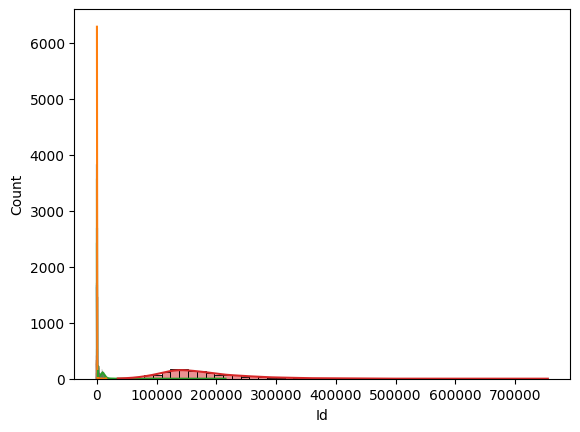

In [169]:
#Distribution of Numerical Columns

for column in train_df.select_dtypes(include = 'number').columns:
    if column in ['MSSubClass','OverallQual', 'OverallCond','MoSold']:
          continue 
    sns.histplot(x=column, data=train_df,kde=True)
    plt.show
    

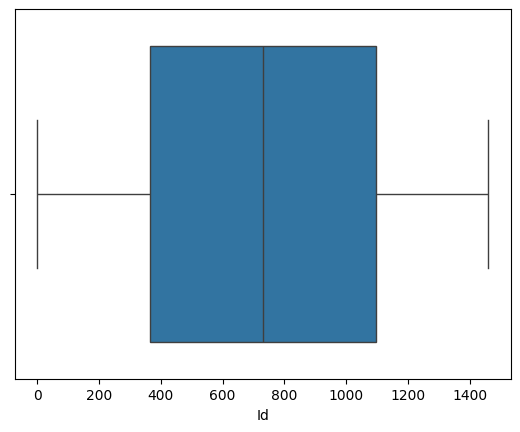

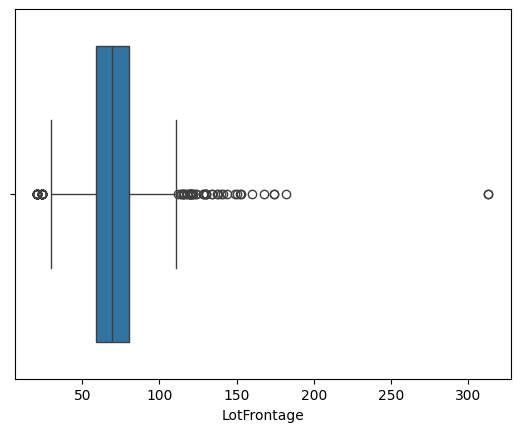

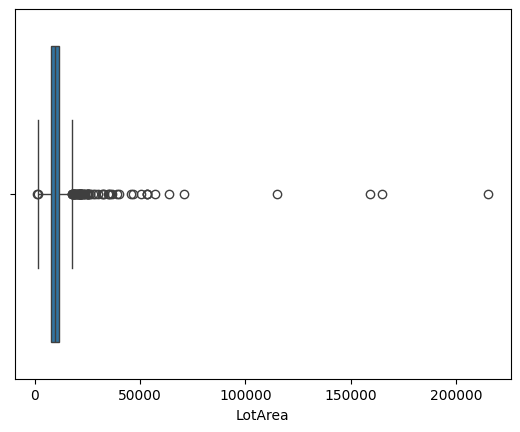

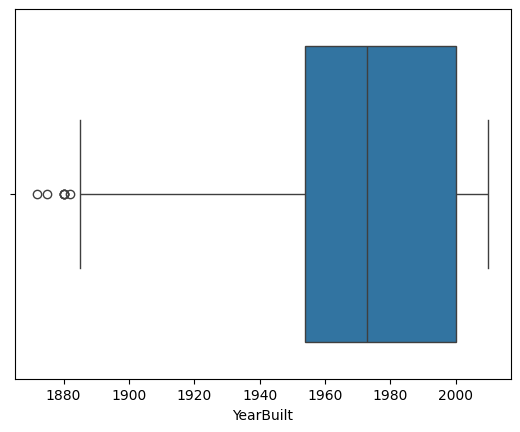

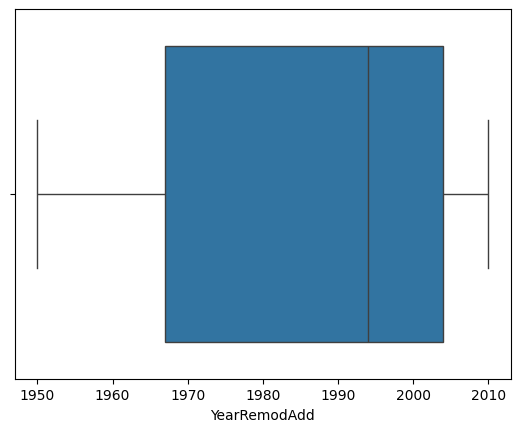

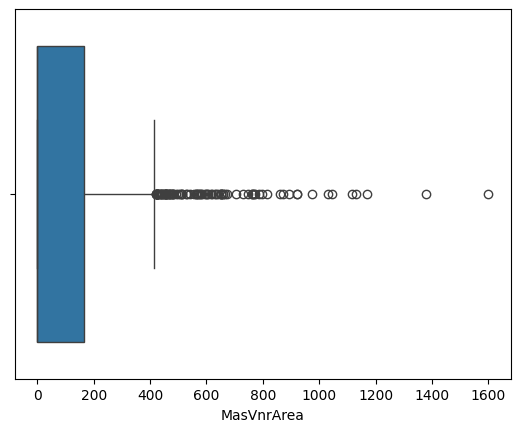

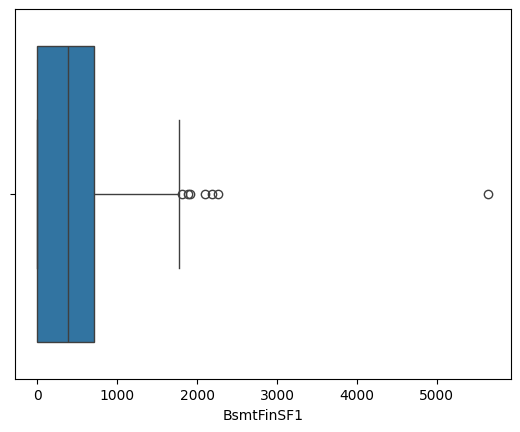

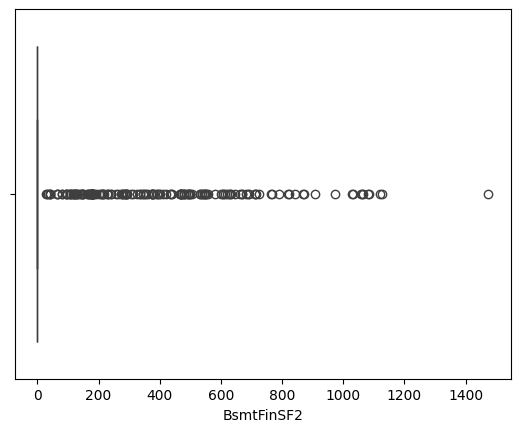

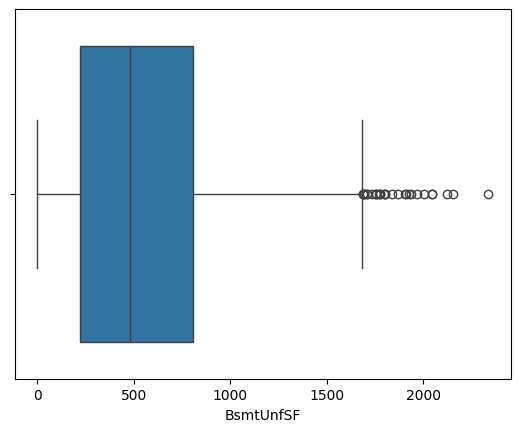

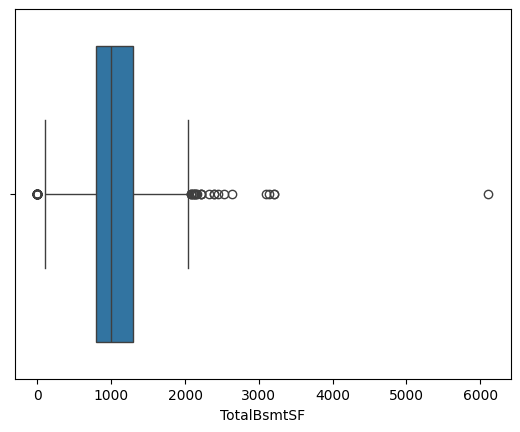

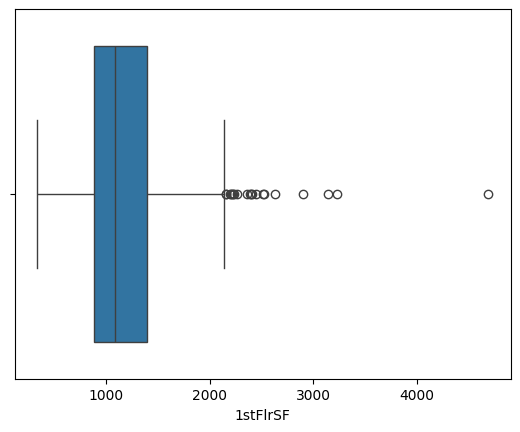

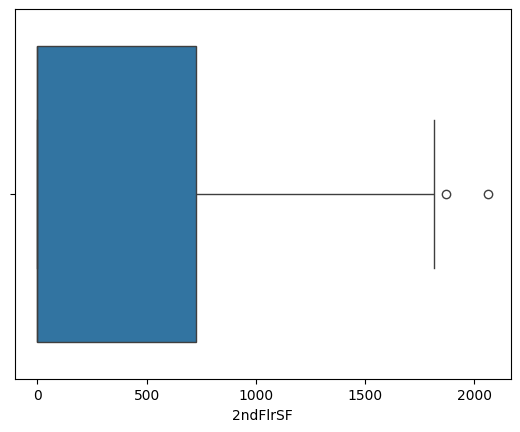

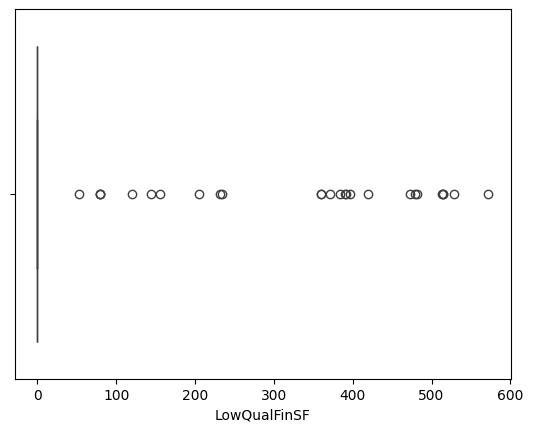

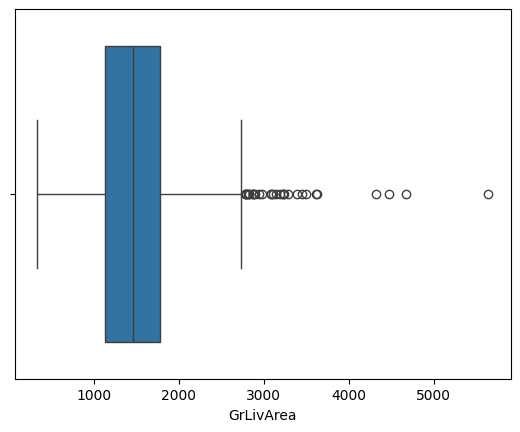

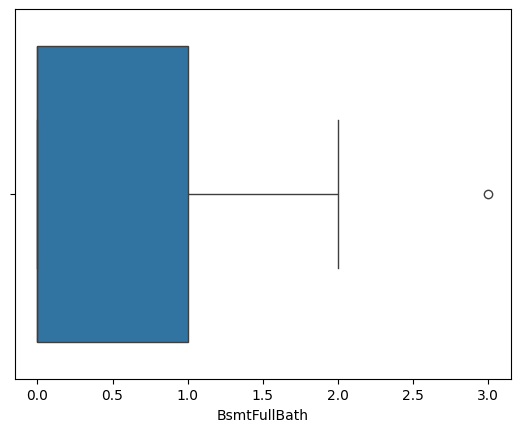

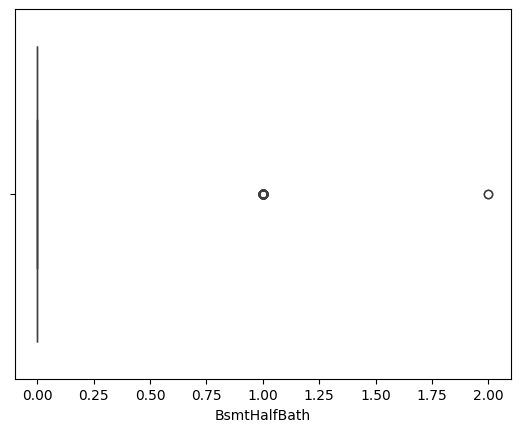

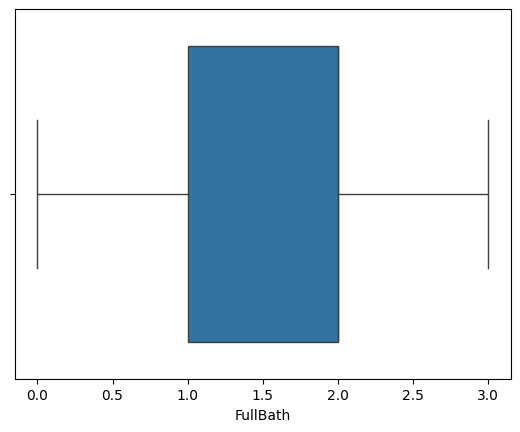

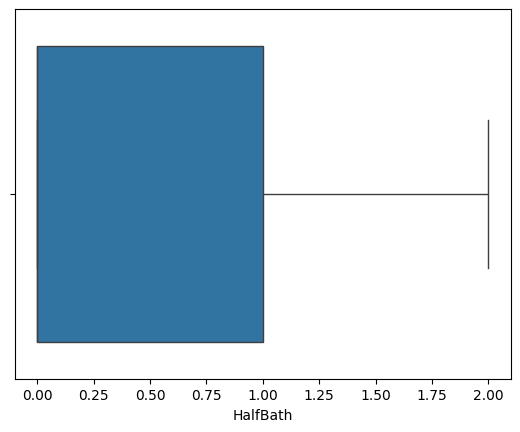

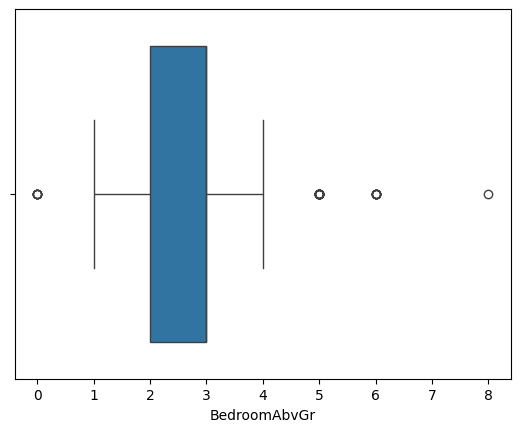

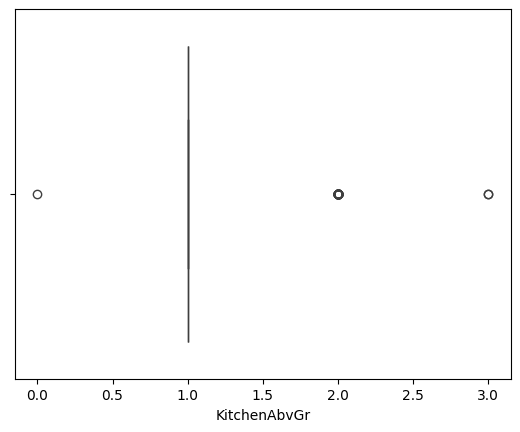

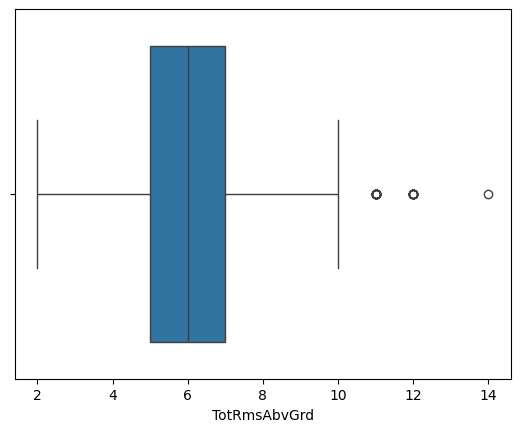

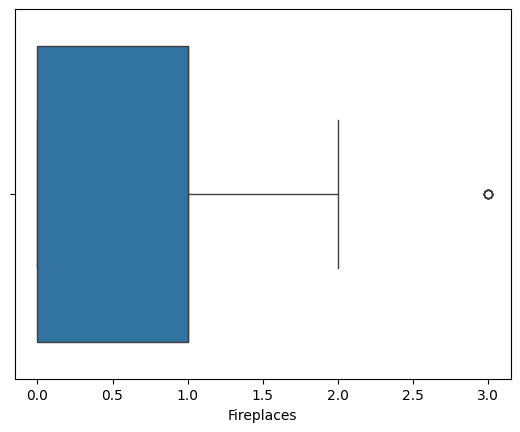

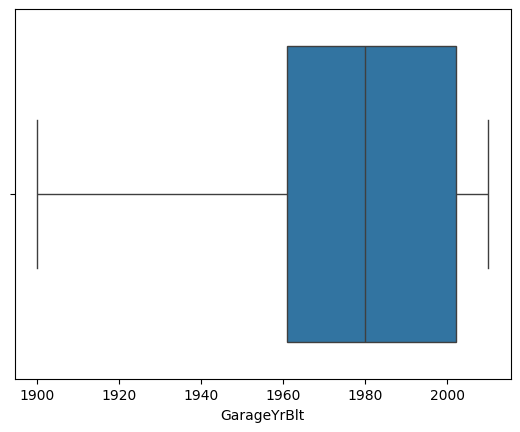

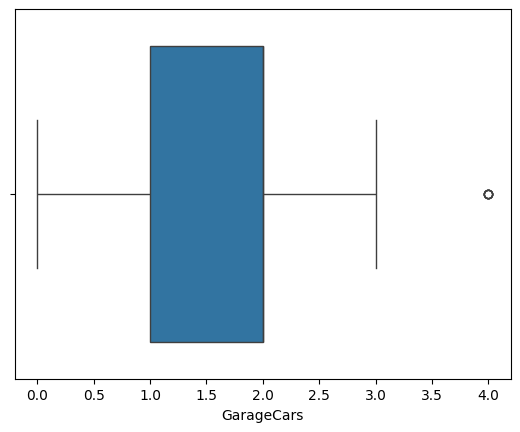

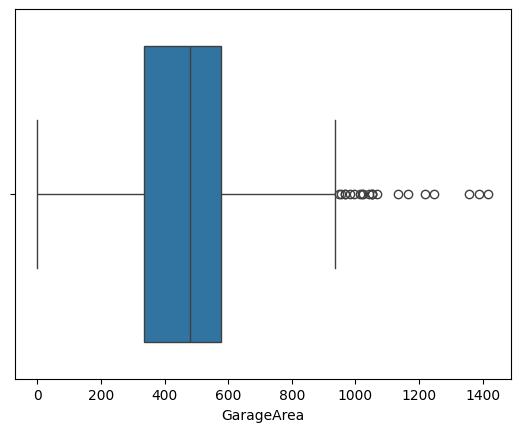

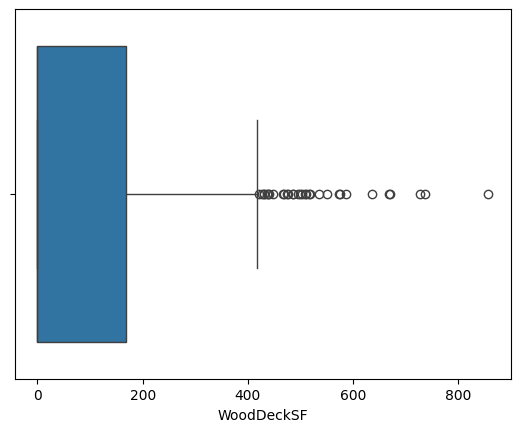

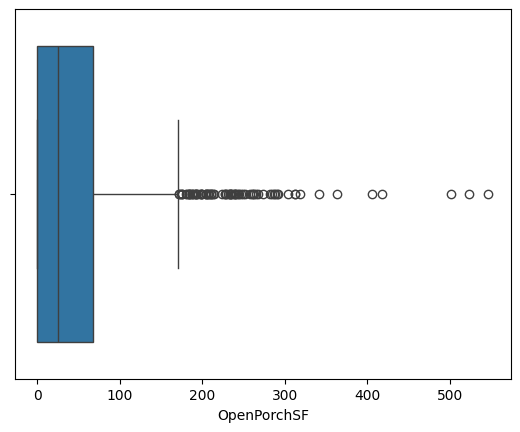

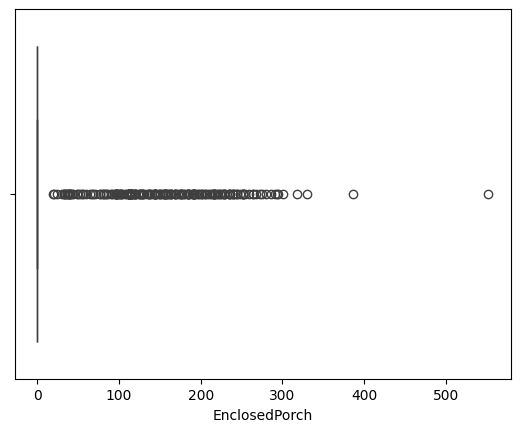

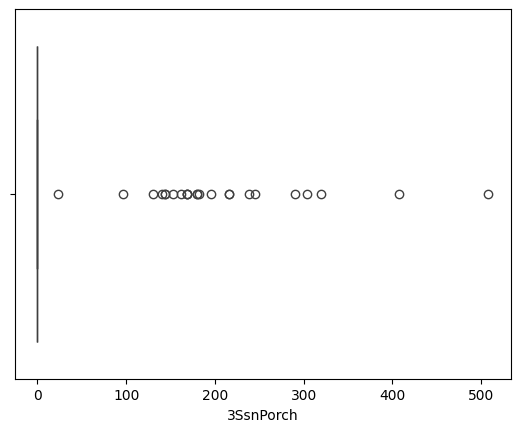

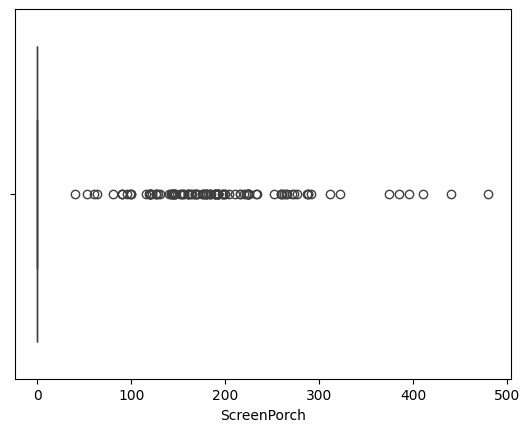

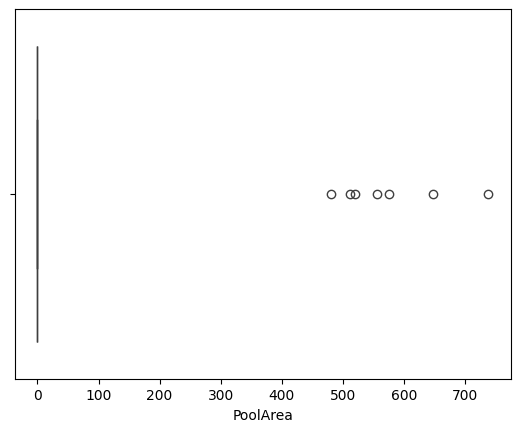

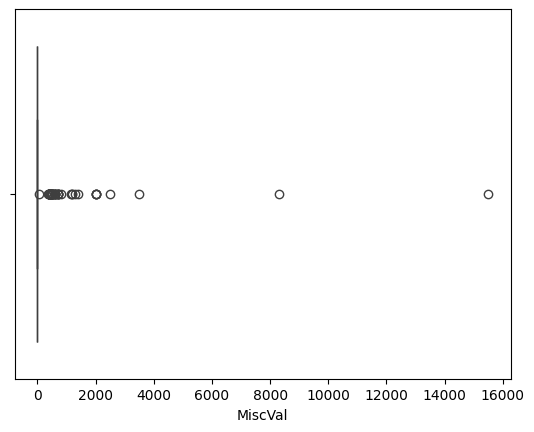

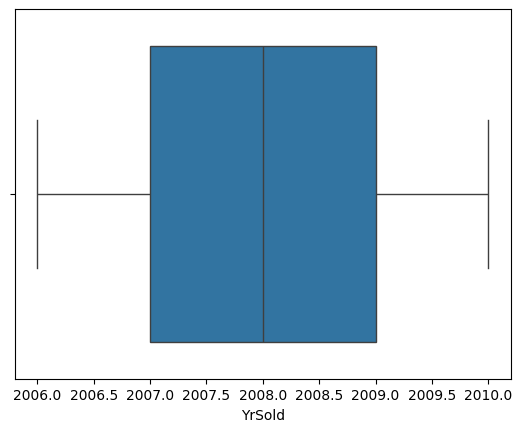

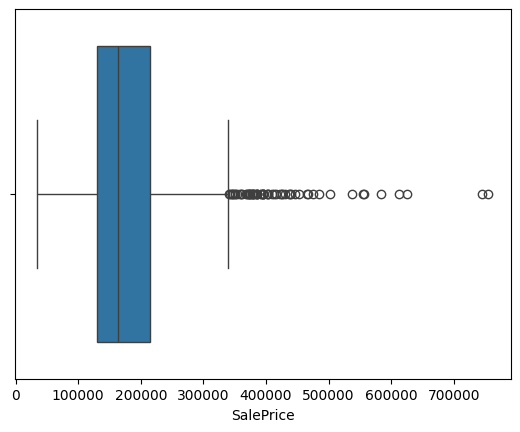

In [170]:

for column in train_df.select_dtypes(include = 'number').columns:
    if column in ['MSSubClass','OverallQual', 'OverallCond','MoSold']:
          continue 
    sns.boxplot(x=column, data=train_df)
    plt.show()               #this shows the median and outliers in the numerical columns  """

2- Distribution of features vs the target 

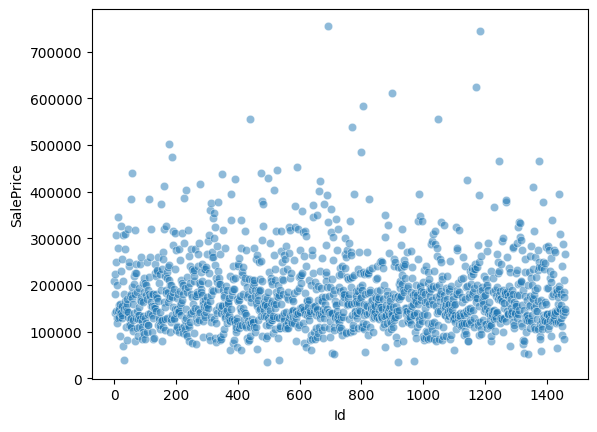

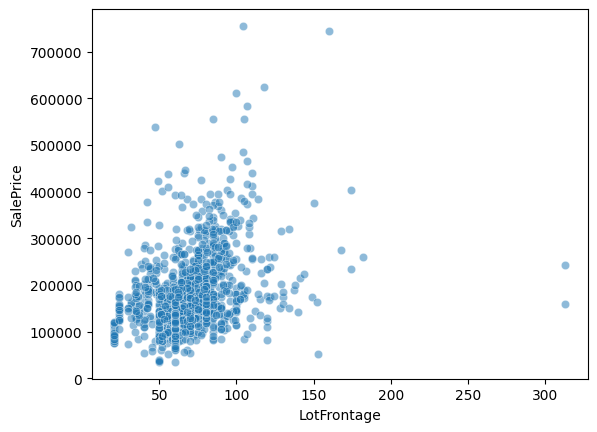

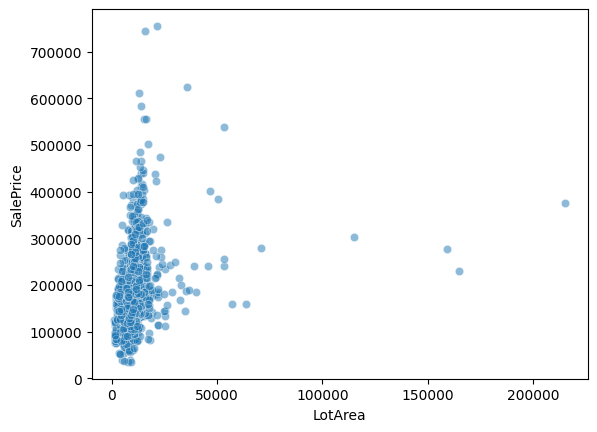

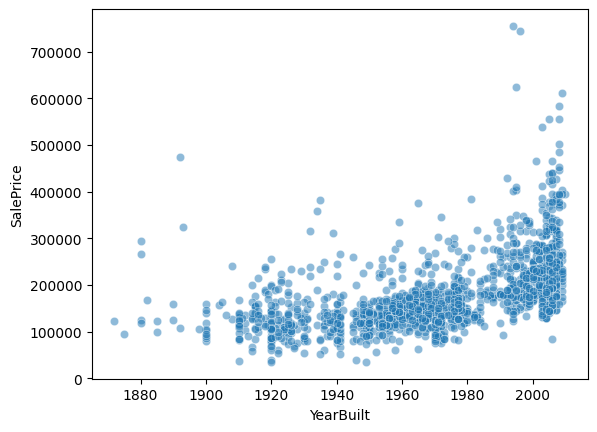

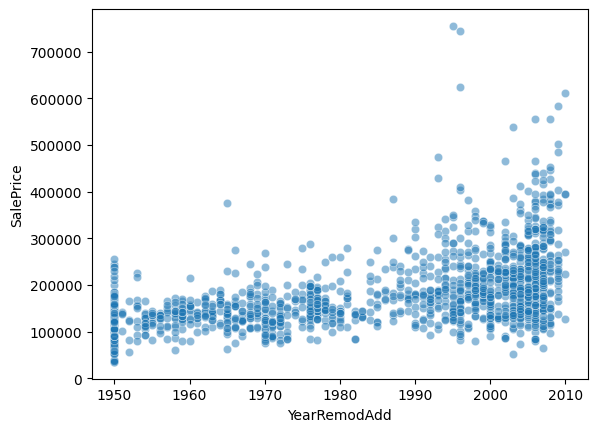

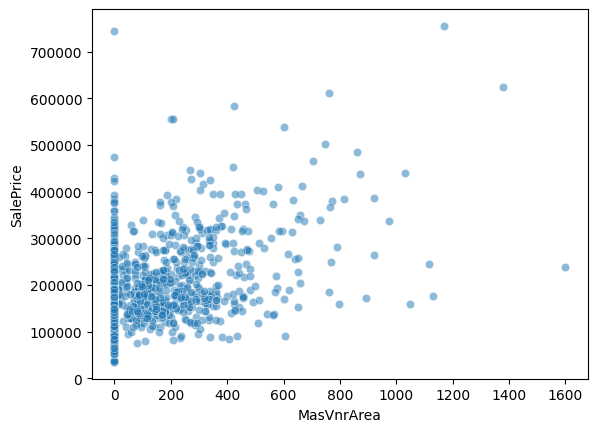

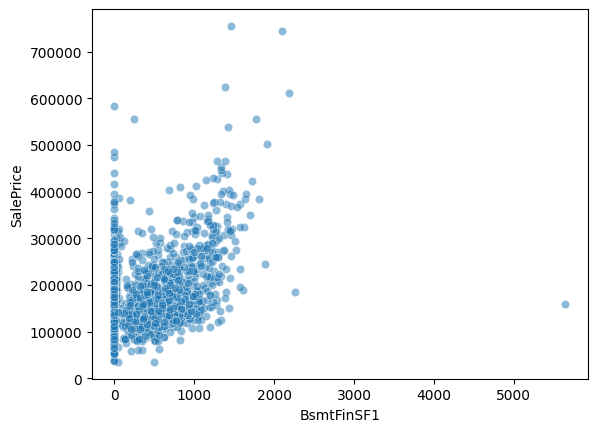

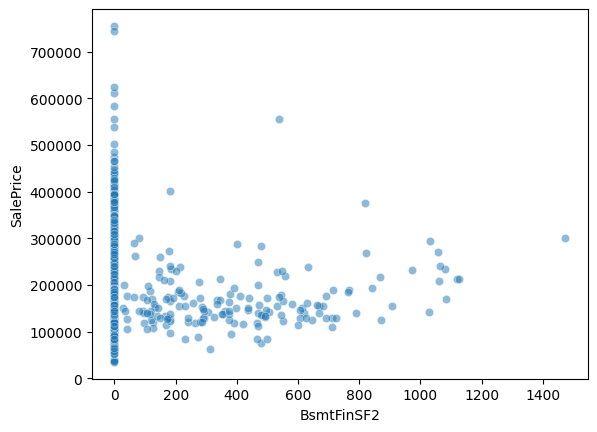

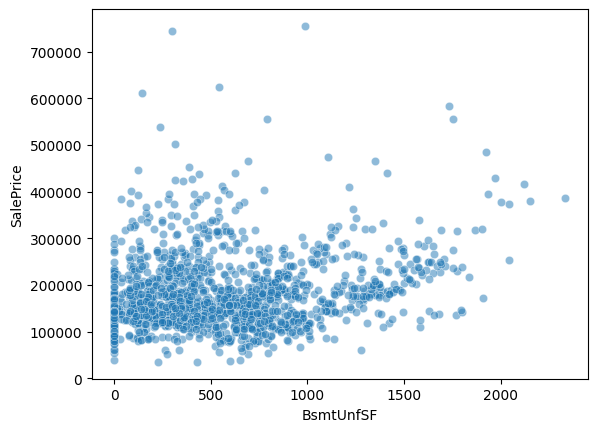

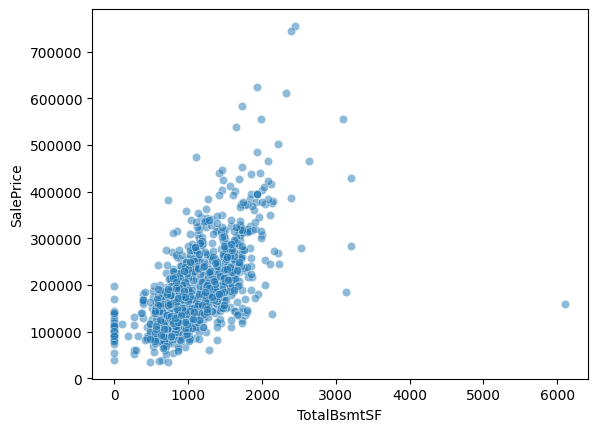

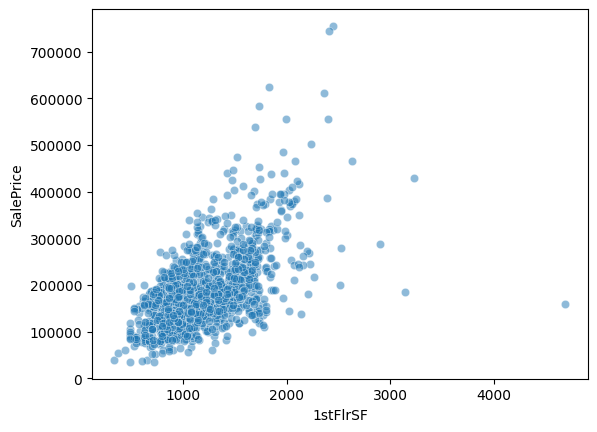

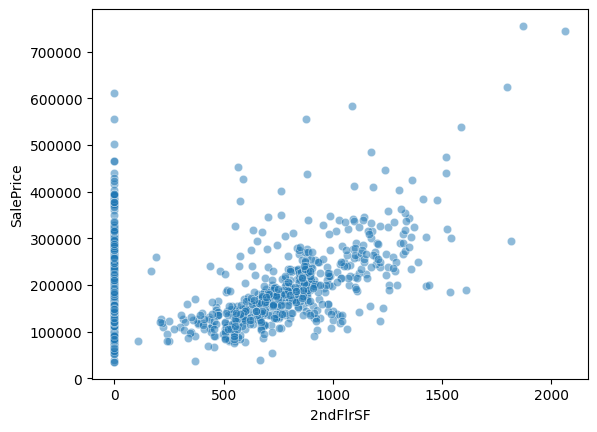

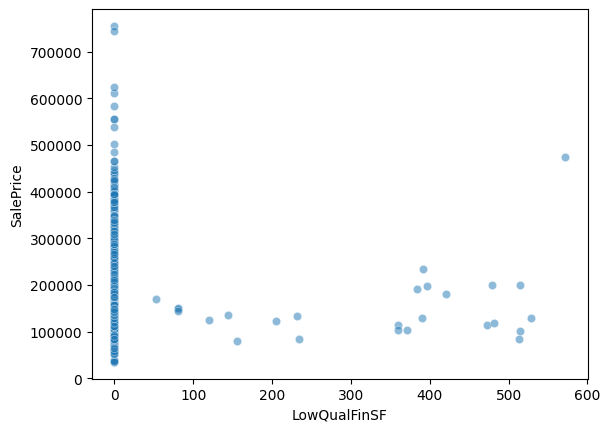

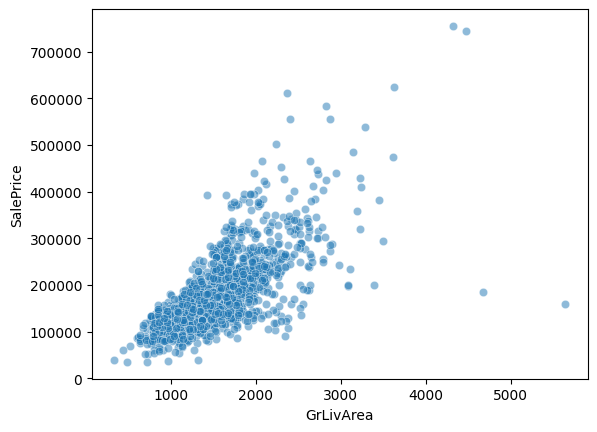

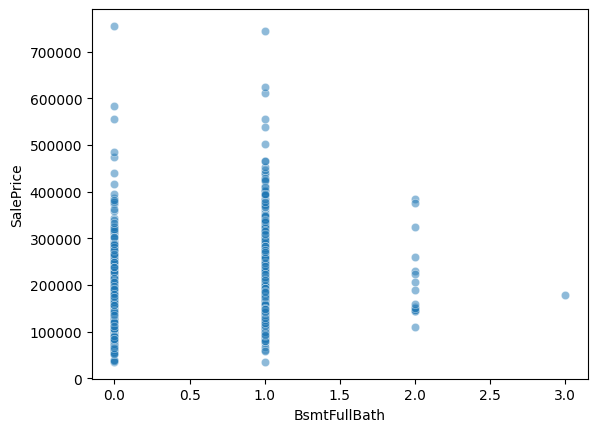

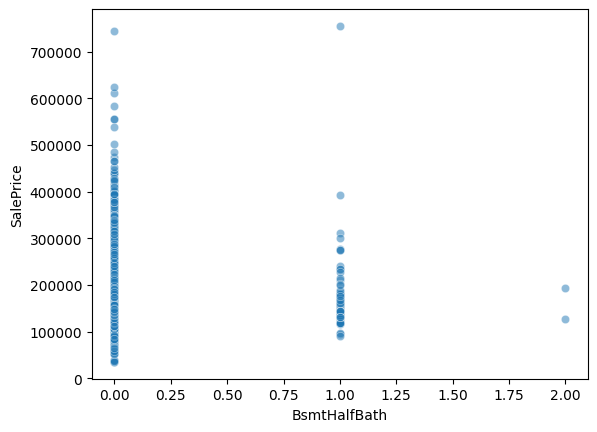

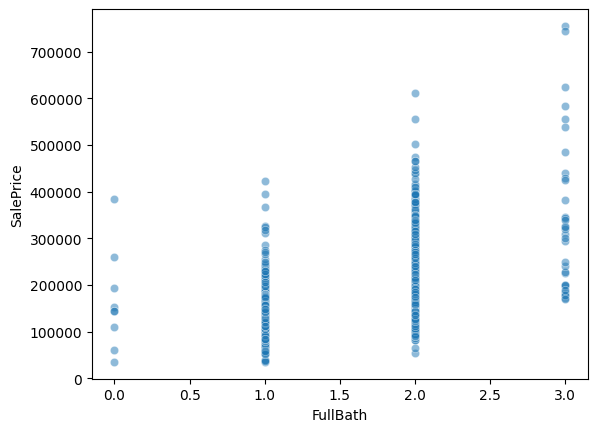

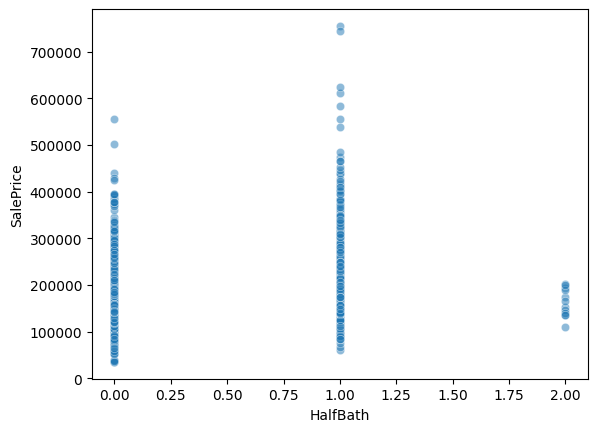

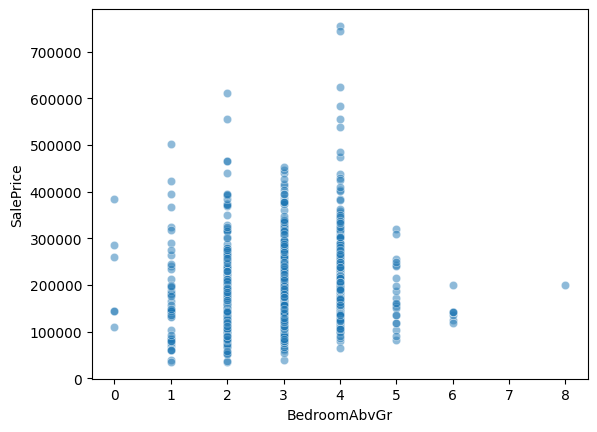

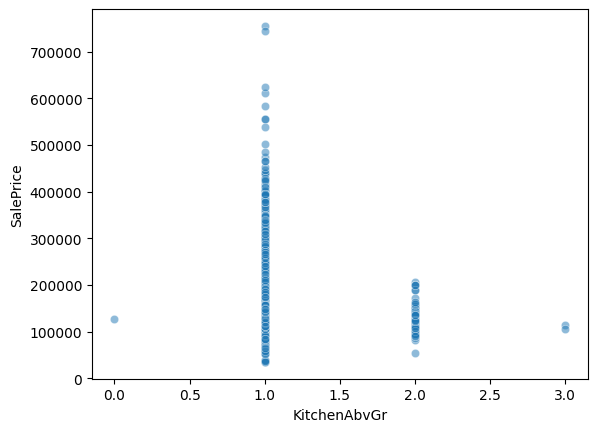

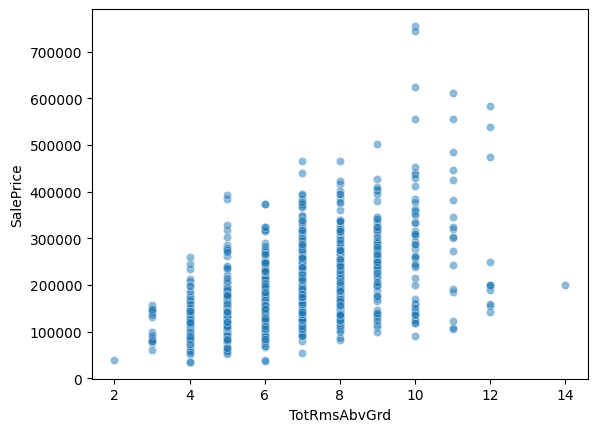

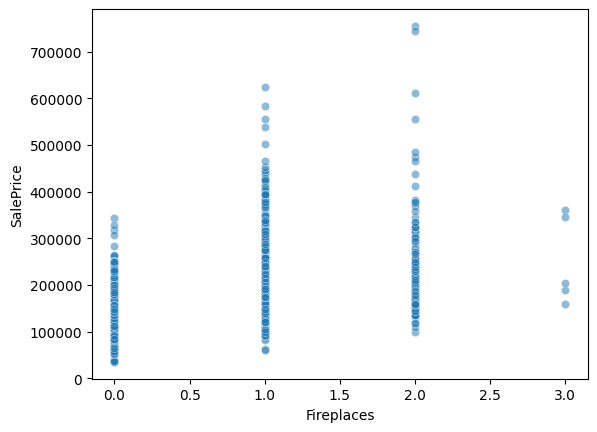

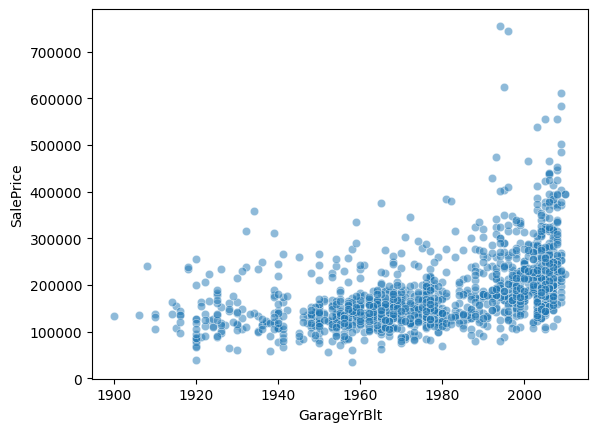

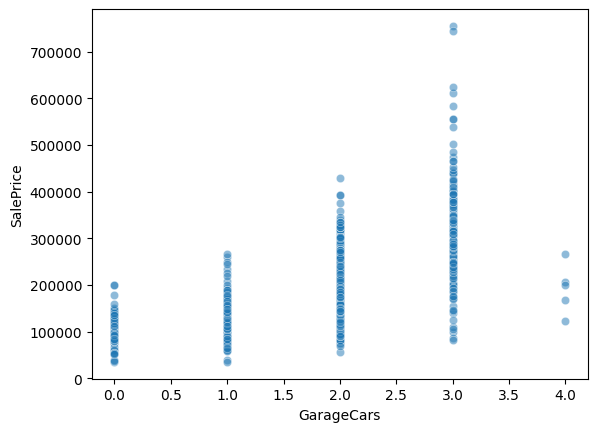

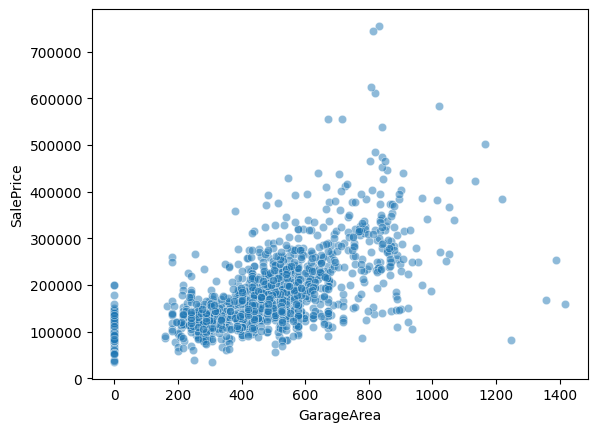

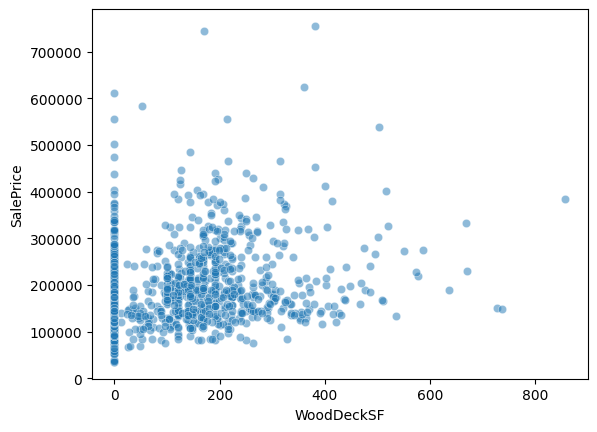

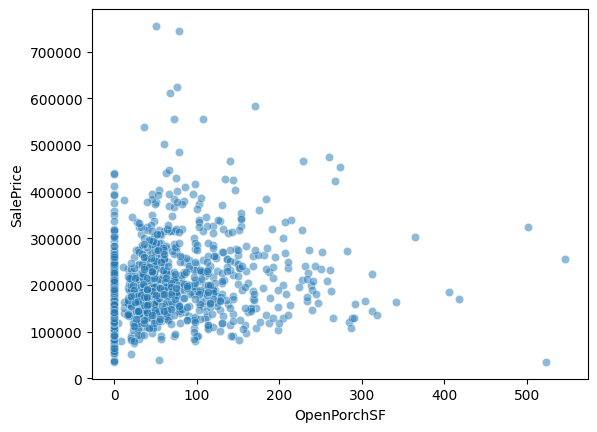

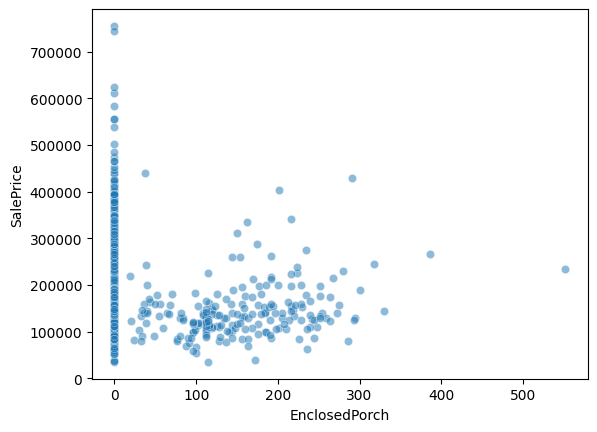

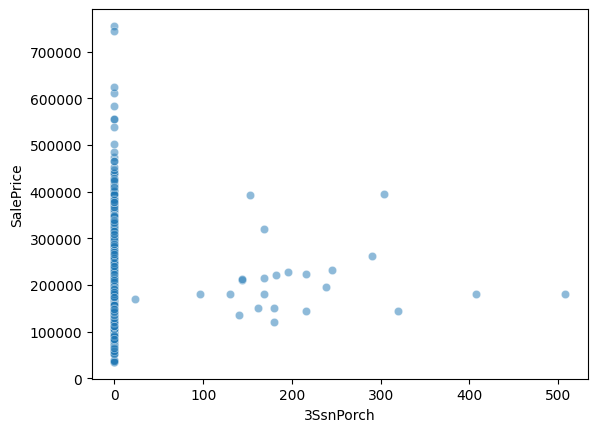

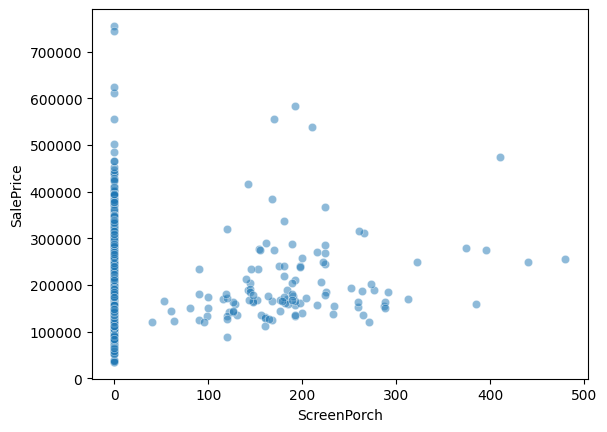

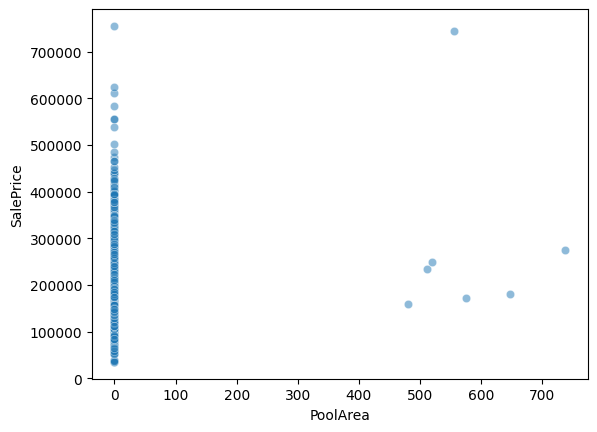

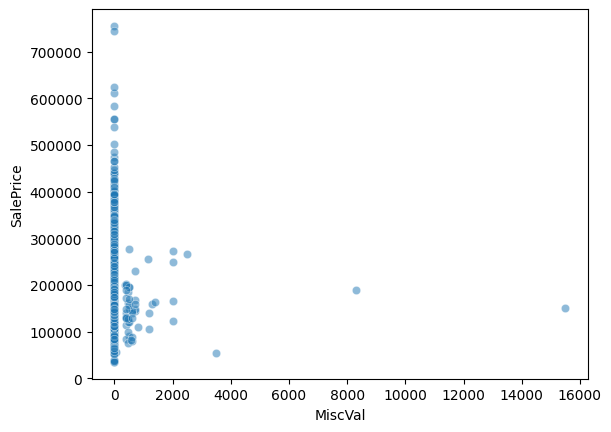

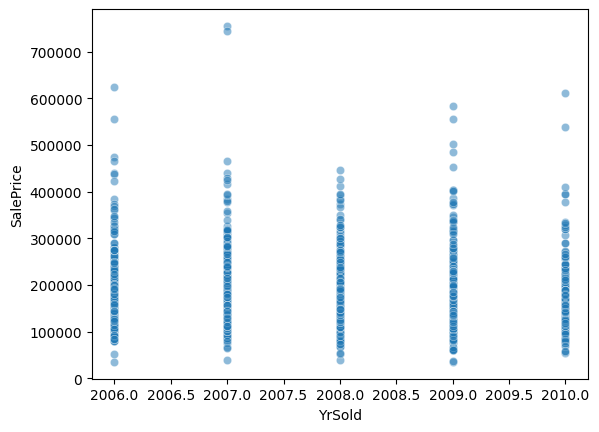

In [171]:
 for column in train_df.select_dtypes(include = 'number').columns:
    if column in ['MSSubClass','OverallQual', 'OverallCond','MoSold','SalePrice']:
          continue 
    sns.scatterplot(x=column,y='SalePrice', data=train_df,alpha=0.5)
    plt.show()
  #this shows the relationship between the target and the numerical columns  """

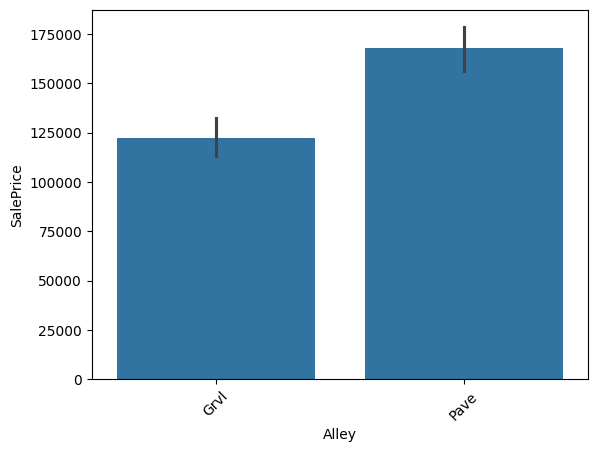

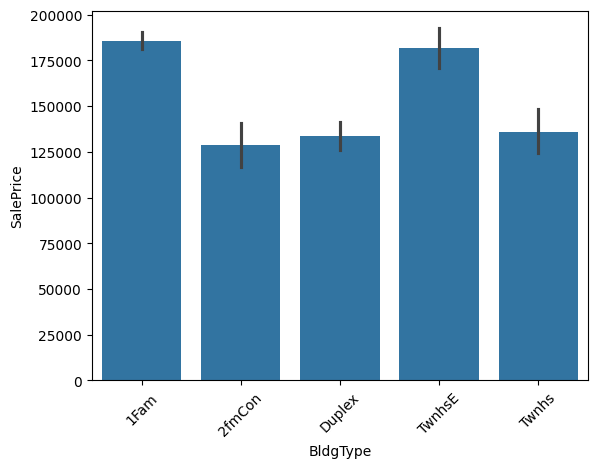

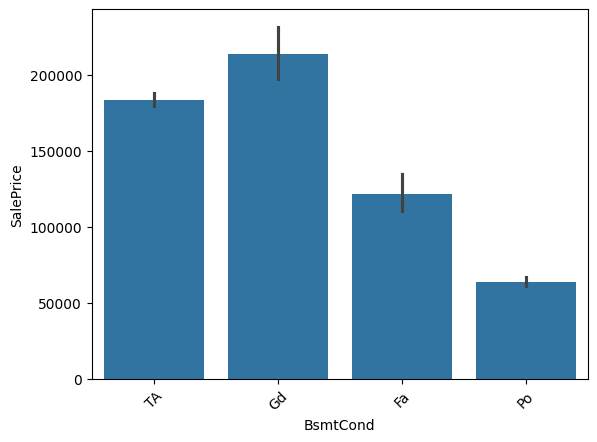

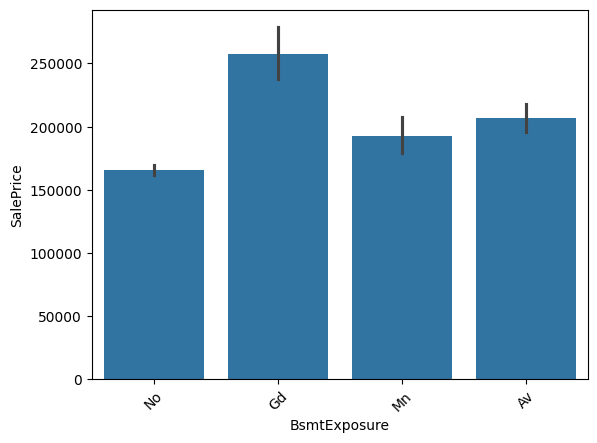

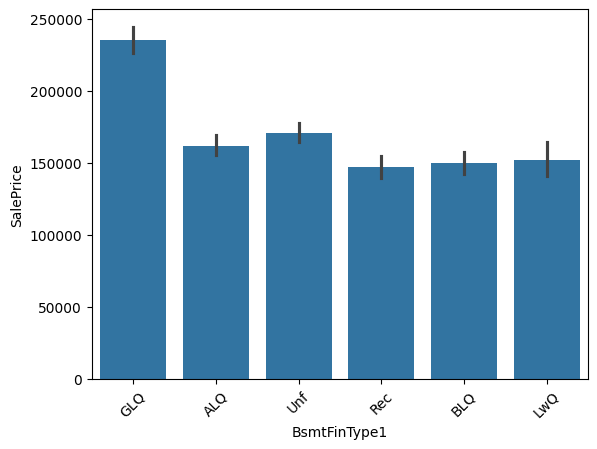

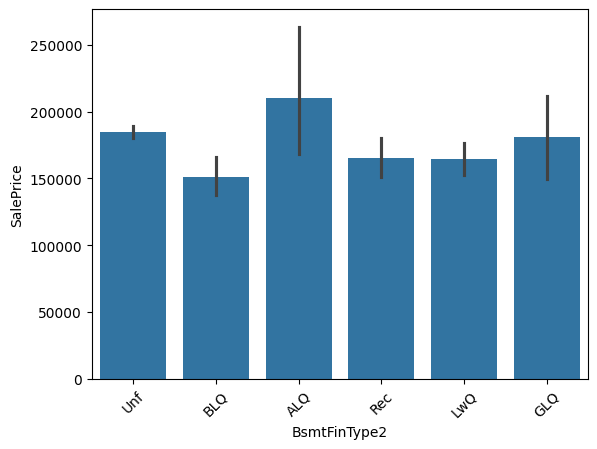

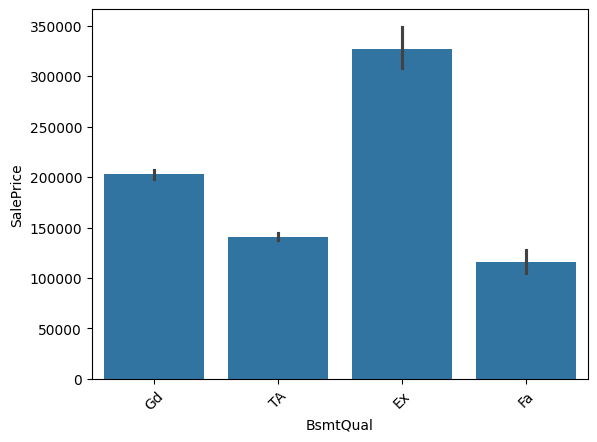

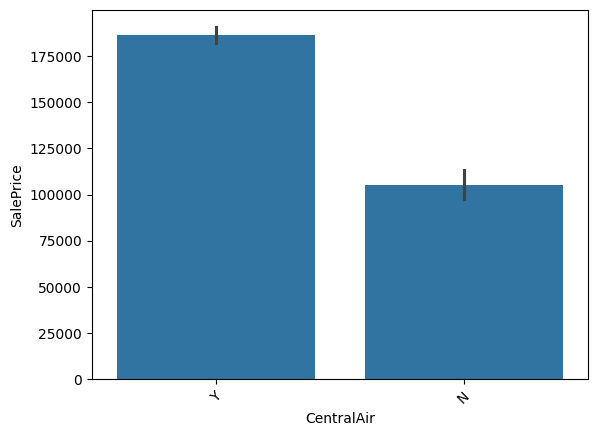

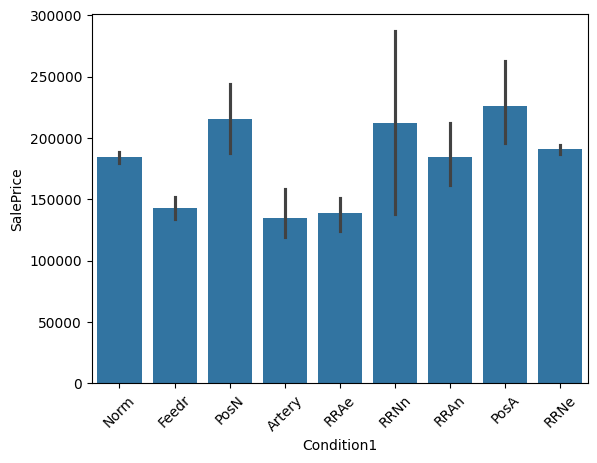

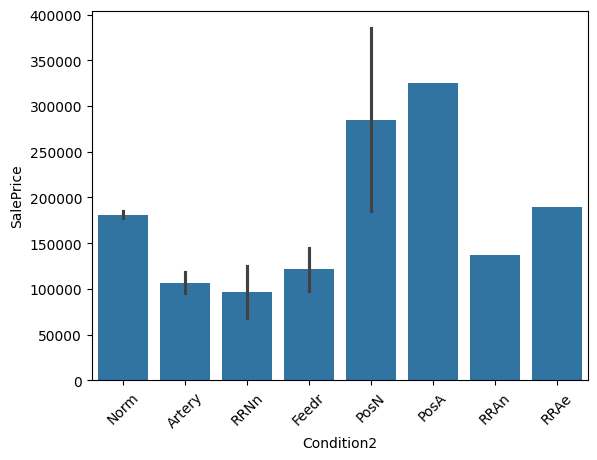

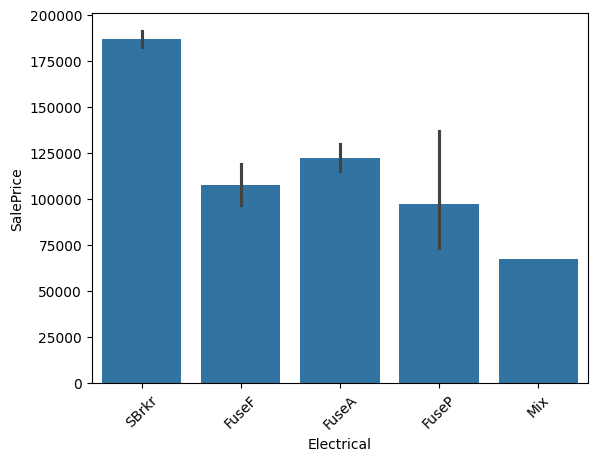

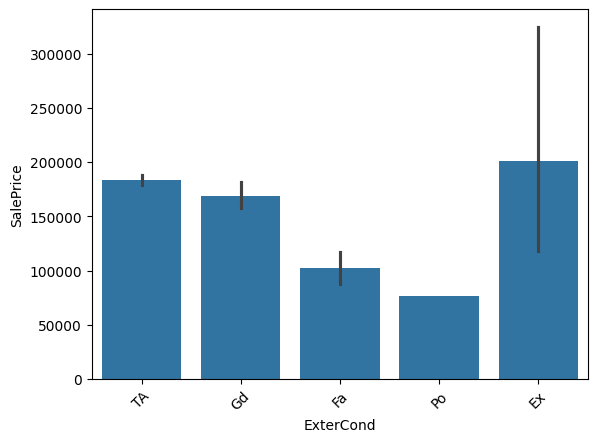

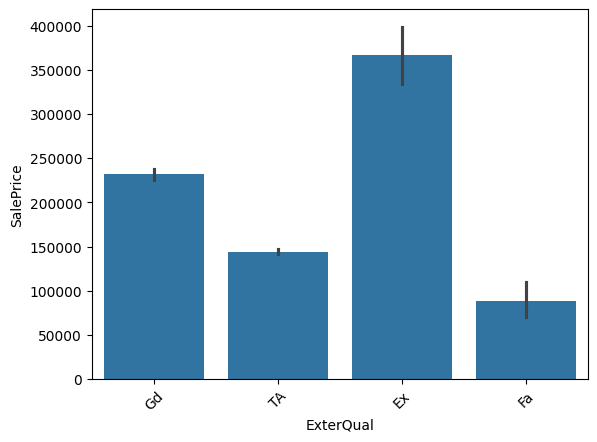

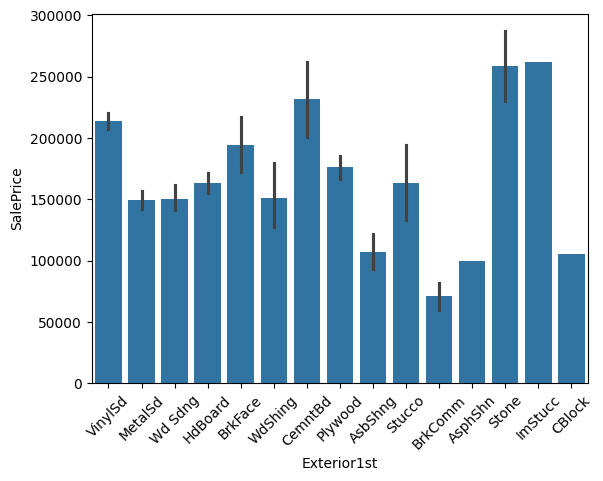

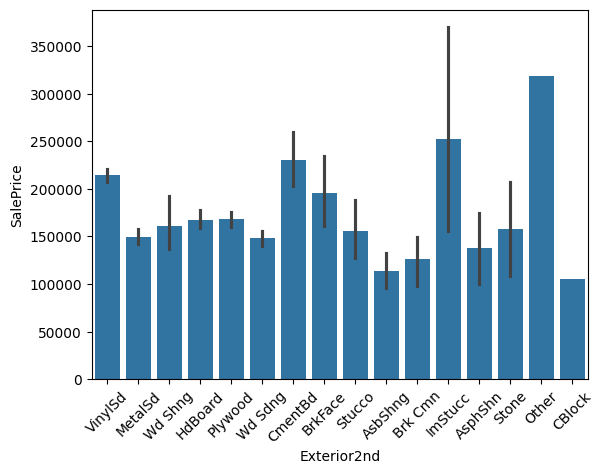

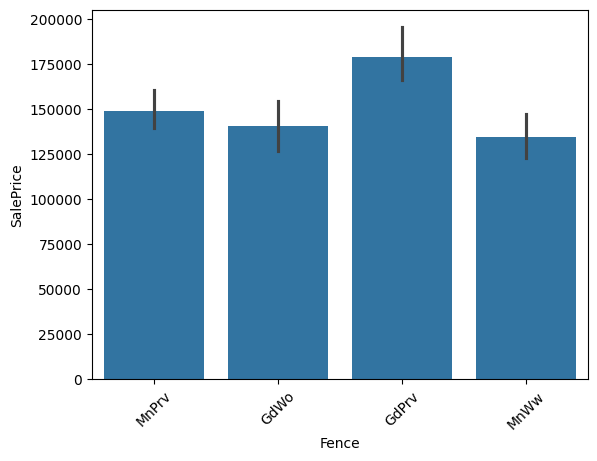

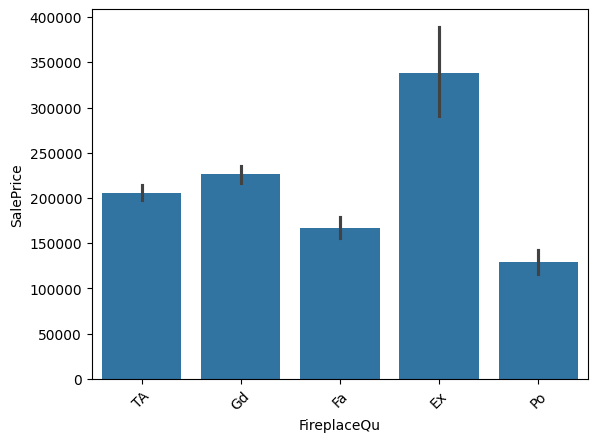

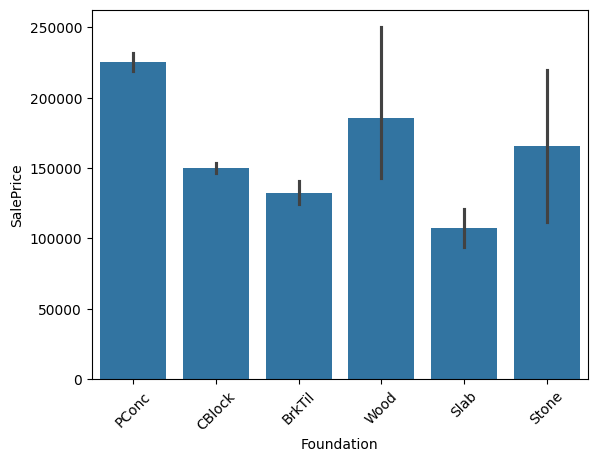

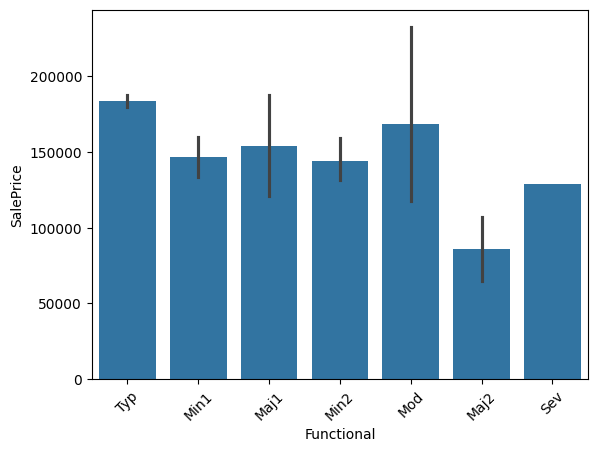

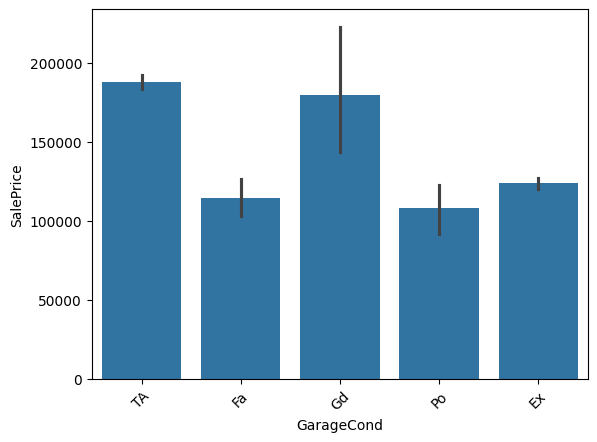

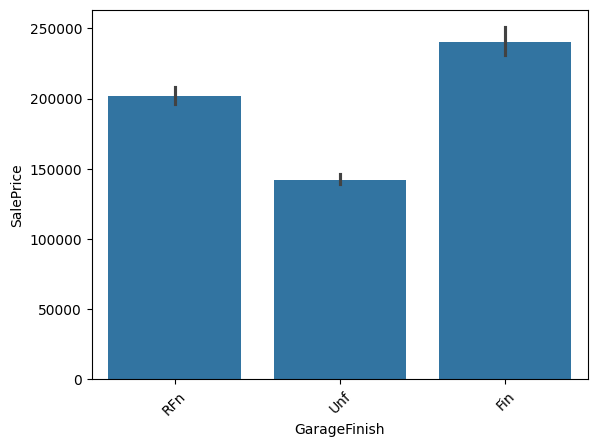

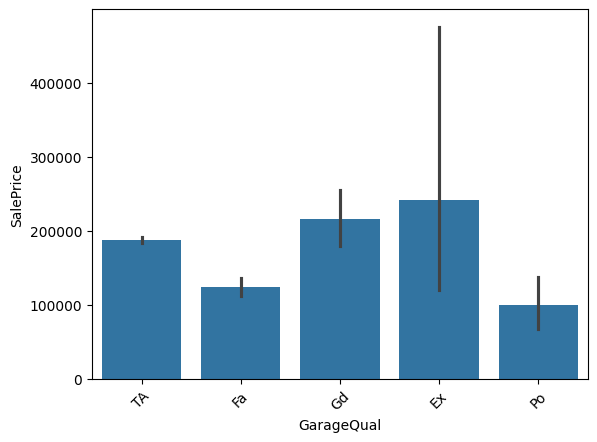

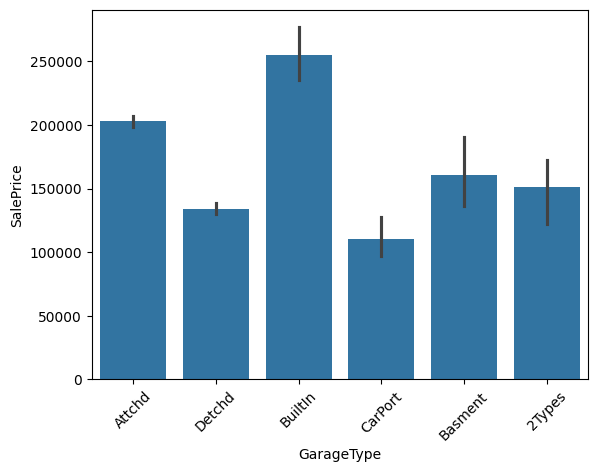

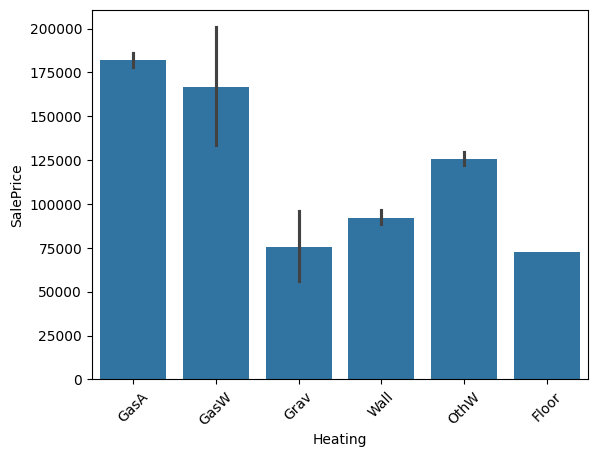

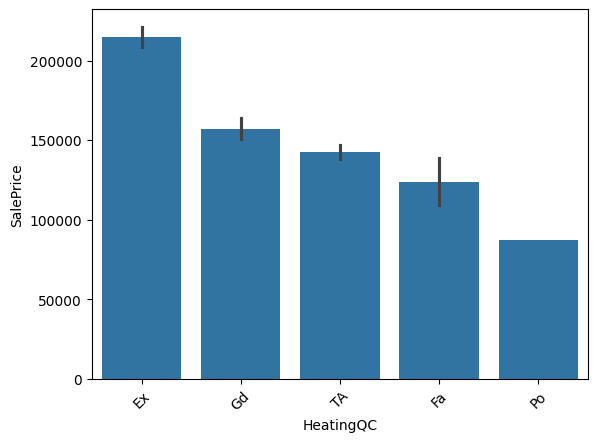

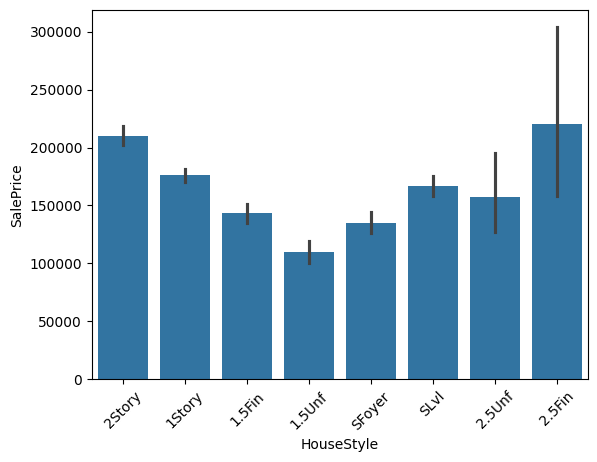

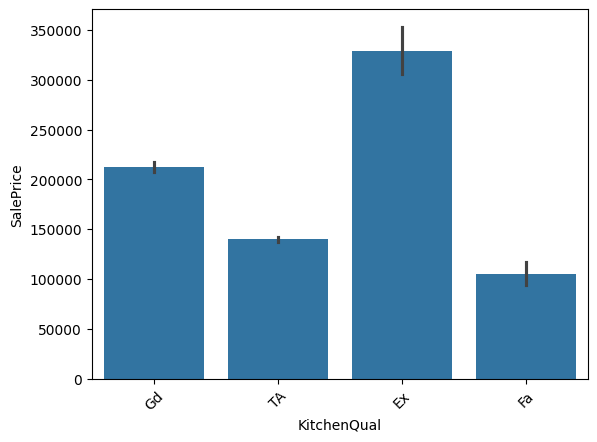

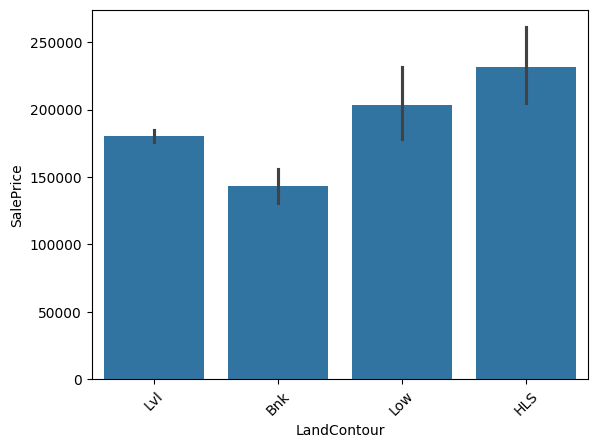

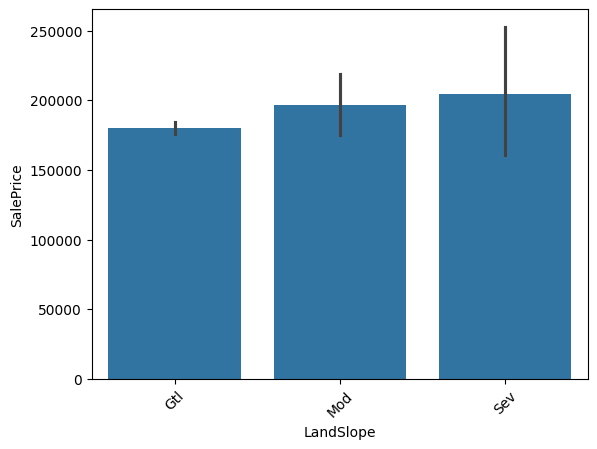

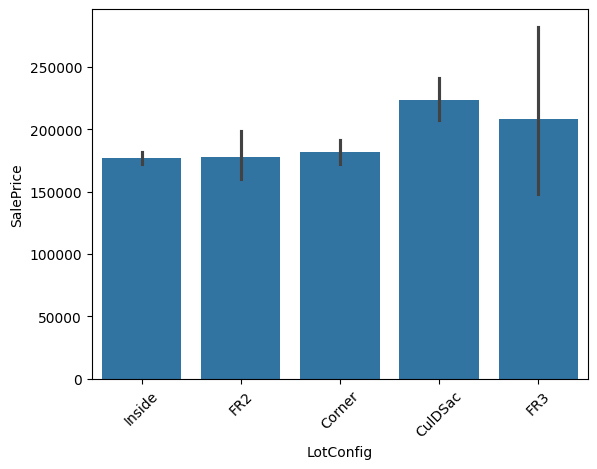

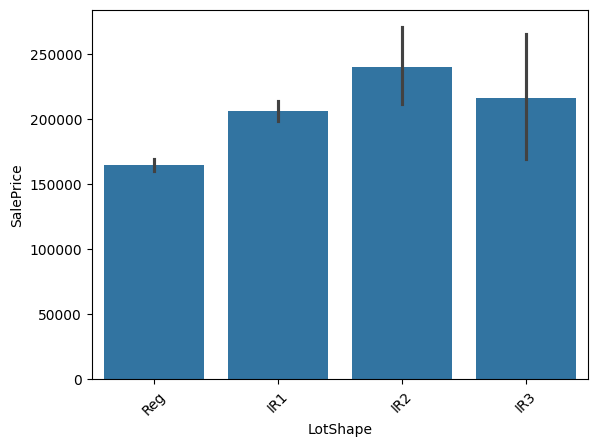

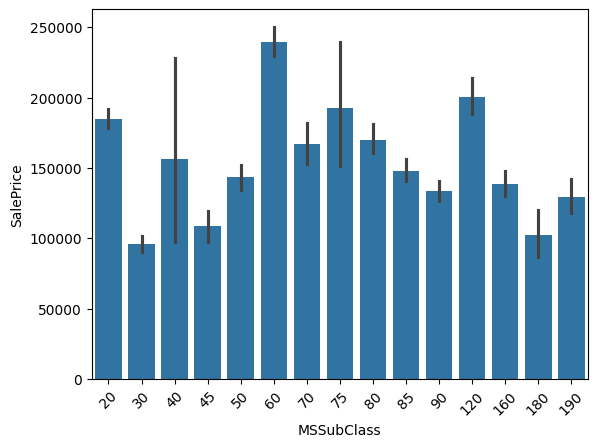

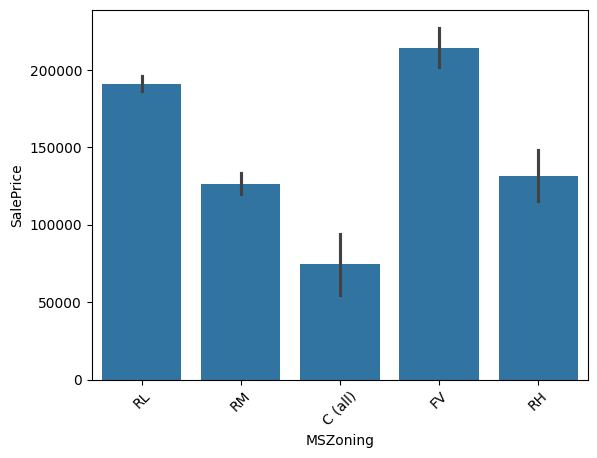

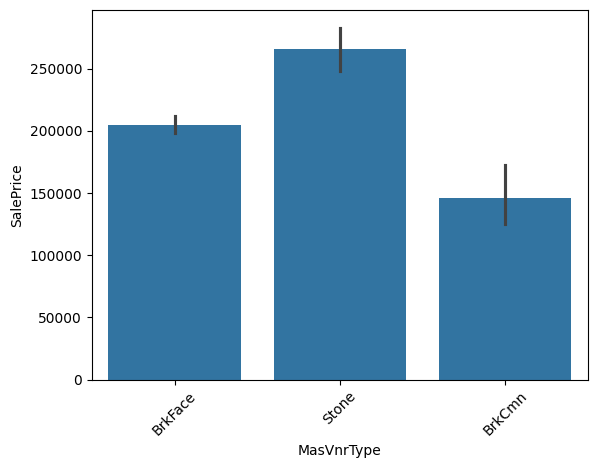

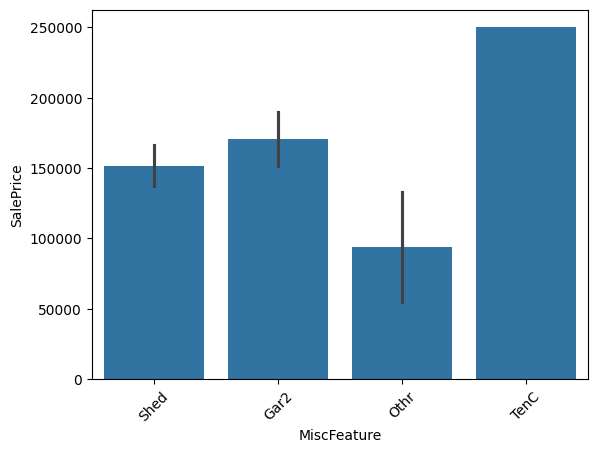

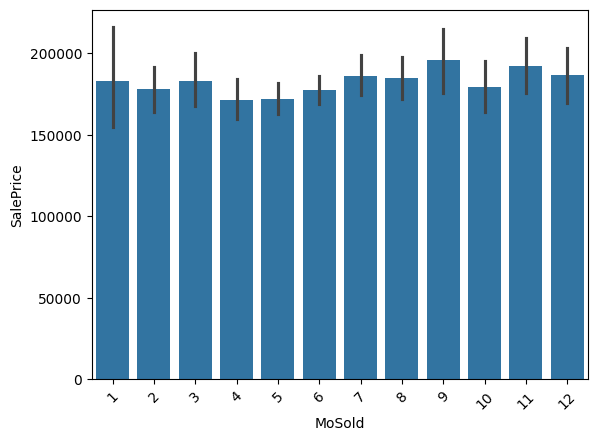

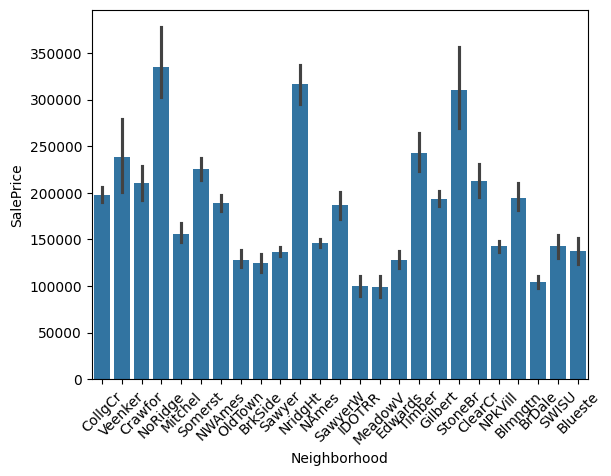

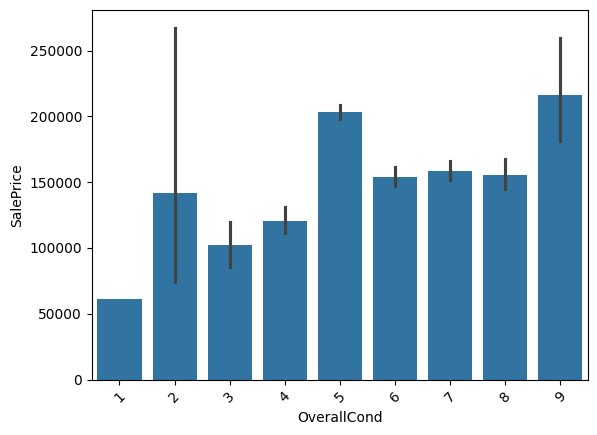

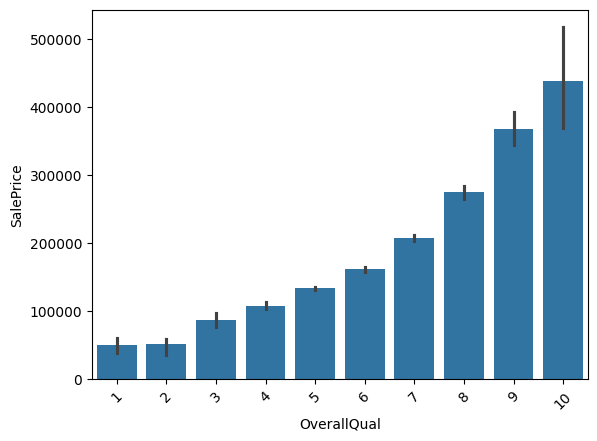

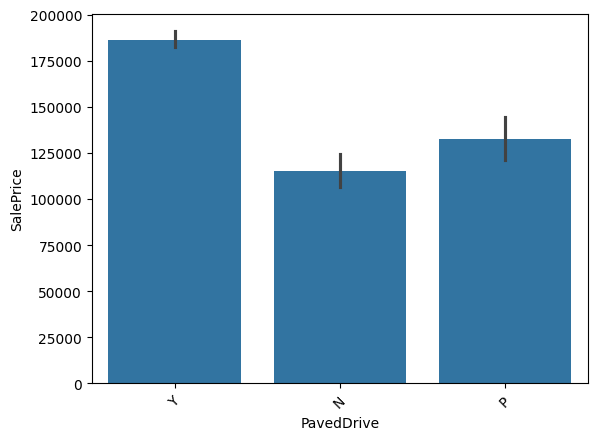

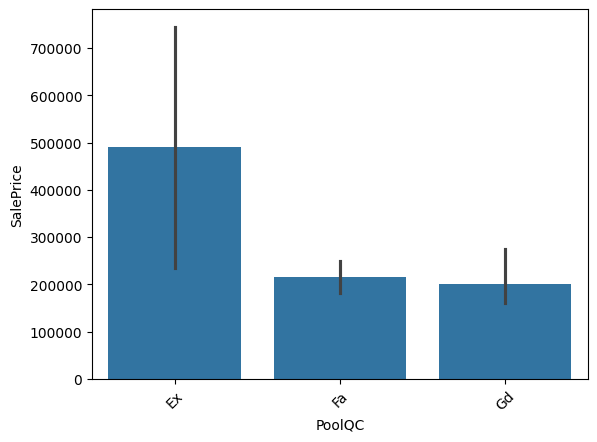

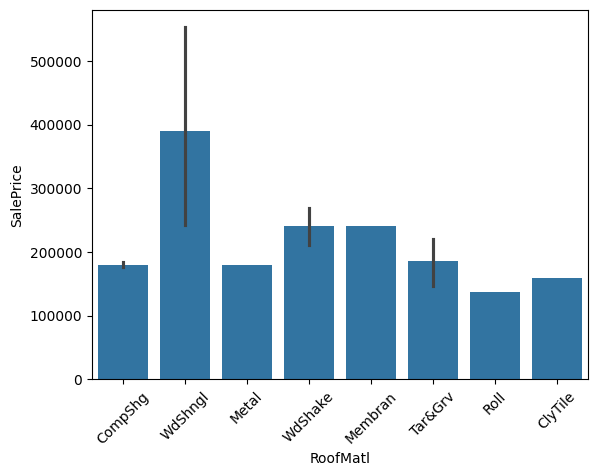

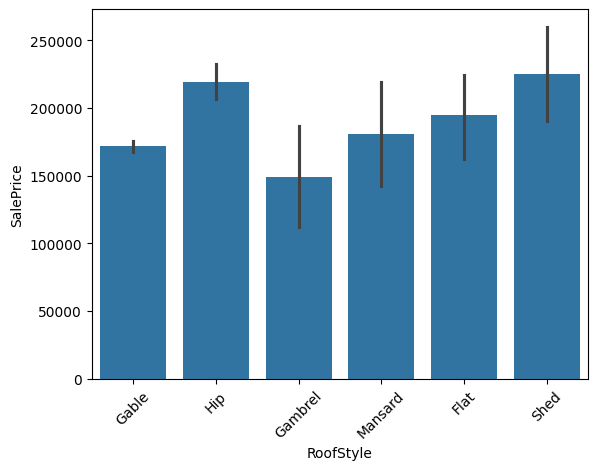

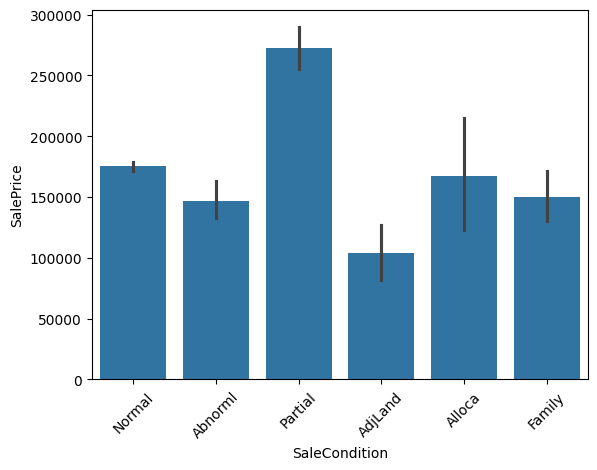

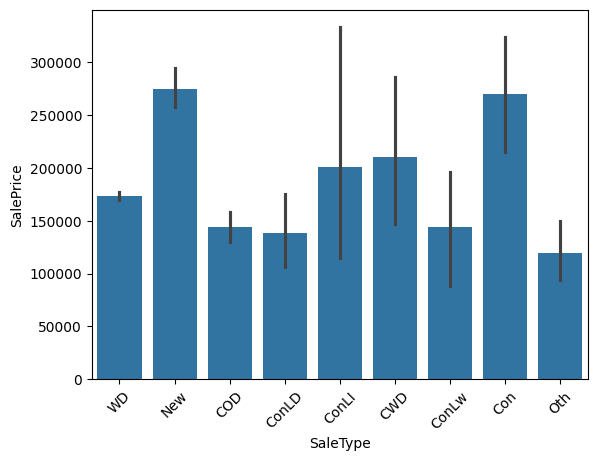

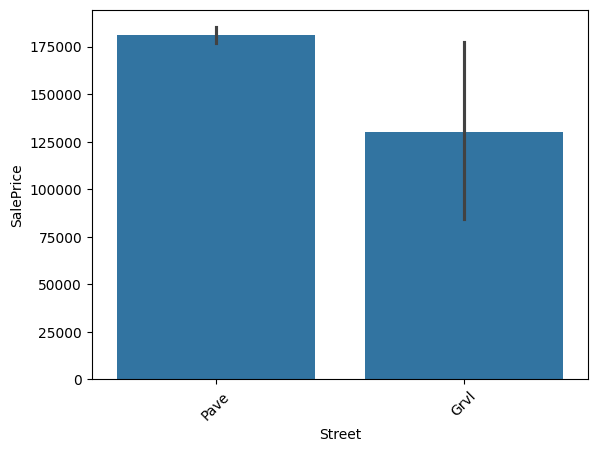

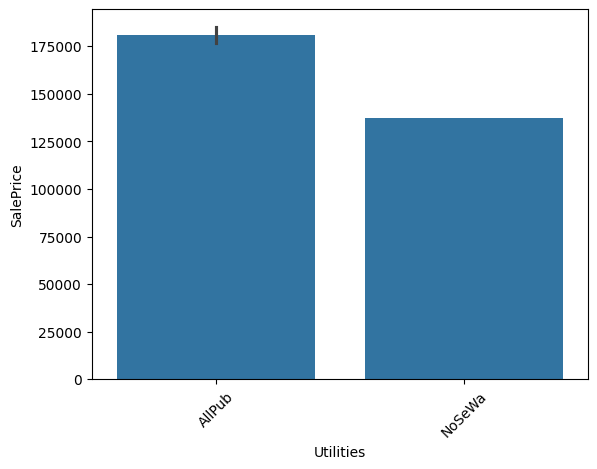

In [172]:
 
for column in train_df.select_dtypes(include = 'object').columns.union(['MSSubClass','OverallQual', 'OverallCond','MoSold']):
    if column == 'SalePrice':
        continue
    sns.barplot(x=column,y='SalePrice', data=train_df)
    plt.xticks(rotation=45)
    plt.show()
#this shows the relationship between the categorical features and the target  """

3-Correlation of numerical features with target 

In [173]:
corr_matrix = train_df[train_df.select_dtypes(include='number').columns].corr() #selected only numerical columns to see correlation between all of them 
#corr_matrix['SalePrice'].sort_values(ascending=False)  # shows only the correlation with the target starting from ver strong correlation to low 

4-Distributions of missing values 

In [174]:
missing=train_df.isnull().sum().sort_values(ascending=False)
missing_values =missing[missing>0]   #filter only missing values 
#sns.barplot(x=missing_values.index, y=missing_values.values)   #shows the number of missing values per column that has missing values 
#plt.xticks(rotation=90)

In [175]:
"""
sns.heatmap(train_df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show() #The heatmap  visualizes the pattern of missing values across the dataset """

'\nsns.heatmap(train_df.isnull(), cbar=False)\nplt.title("Missing Values Heatmap")\nplt.show() #The heatmap  visualizes the pattern of missing values across the dataset '

# 5-Data Cleaning & Reprocessing 


1-Handling missing Values (everything i modify on the training dataset will also be modifid in the testing one)

In [176]:
#missing_values_percentage=(missing_values / train_df.shape[0]) * 100
#columns with more than or equal 90 percent missing values will be dropped 
train_df.drop(['PoolQC','MiscFeature','Alley'],axis=1,inplace=True,errors='ignore')   
test_df.drop(['PoolQC','MiscFeature','Alley'],axis=1,inplace=True,errors='ignore') 

In [177]:
#fixing the null values by replacing them with a new category 
train_df['MasVnrType'] = train_df['MasVnrType'].fillna('NoVnr') 
train_df.loc[train_df['MasVnrType'] == 'NoVnr', 'MasVnrArea'] = 0 #for the houses that doesnt habe MasVnr , MasVnrArea will be set to zero 
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna('NoFirePlace')   
train_df['Fence'] = train_df['Fence'].fillna('NoFence')   
train_df[['GarageType','GarageCond','GarageFinish','GarageQual']] = train_df[['GarageType','GarageCond','GarageFinish','GarageQual']].fillna('NoGarage') 
train_df[['BsmtExposure','BsmtFinType2','BsmtFinType1','BsmtQual','BsmtCond']] = train_df[['BsmtExposure','BsmtFinType2','BsmtFinType1','BsmtQual','BsmtCond']].fillna('NoBsmt')

test_df['MasVnrType'] = test_df['MasVnrType'].fillna('NoVnr') 
test_df.loc[test_df['MasVnrType'] == 'NoVnr', 'MasVnrArea'] = 0 #for the houses that doesnt habe MasVnr , MasVnrArea will be set to zero 
test_df['FireplaceQu'] = test_df['FireplaceQu'].fillna('NoFirePlace')   
test_df['Fence'] = test_df['Fence'].fillna('NoFence')   
test_df[['GarageType','GarageCond','GarageFinish','GarageQual']] = test_df[['GarageType','GarageCond','GarageFinish','GarageQual']].fillna('NoGarage') 
test_df[['BsmtExposure','BsmtFinType2','BsmtFinType1','BsmtQual','BsmtCond']] = test_df[['BsmtExposure','BsmtFinType2','BsmtFinType1','BsmtQual','BsmtCond']].fillna('NoBsmt')




#neighbourhoods are related with lotfrontage that certain neighbourhoods have big lotfrontage and vise versa , so i will fill them with the median of 
#the lotfrontage grouped by neighbourhood rather than filling them with the overall median 
train_df['LotFrontage'] = train_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
test_df['LotFrontage'] = test_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

#since Electrical only has 0.06 percent missing values i will fill them with the most repeated category (the mode)
train_df['Electrical']=train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])
test_df['Electrical']=test_df['Electrical'].fillna(test_df['Electrical'].mode()[0])

train_df[train_df['GarageYrBlt']==train_df['YearBuilt']].shape[0] / train_df.shape[0] * 100
# this means that for most of the datatset the garage year bulit is the same as the yaer the house was built 
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(train_df['YearBuilt'])
test_df['GarageYrBlt'] = test_df['GarageYrBlt'].fillna(test_df['YearBuilt'])

2 - Outlier detection and transformations 

In [178]:
# from the distributions above i noticed that in the relationship between GrLivArea and SalePrice increase by increasig the other 
#so i noticed that there are some outliers that make no sense that a house with more than 4000 GrlivArea comes with price
#less than 200k  , which can be misleading to the model so i will drop their rows considering they are only two rows 
train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 500000)].index,errors='ignore')
test_df = test_df.drop(test_df[test_df['GrLivArea'] > 4000],errors='ignore') 

In [179]:
# also i noticed from the distributions above that the columns i will mention below are very right skewed , and these outliers on the right 
#side are not false or nonsense vaues they are just rare , which can be informative to the model but since they are skewed i will log transform them 
#because i will be using linear models later and this will be a problem since linear models get affected by outliers 

for col in ['LotArea','LotFrontage','MasVnrArea','1stFlrSF','GrLivArea','GarageArea','SalePrice']:
    train_df[col + "_log"] = np.log1p(train_df[col])

for col in ['LotArea','LotFrontage','MasVnrArea','1stFlrSF','GrLivArea','GarageArea','SalePrice']:
    test_df[col + "_log"] = np.log1p(train_df[col])

3-Feature Engineering (will do the same for testing dataset)

In [180]:
#these columns are right skewed with too many zeros and less for other values so i will make a binary column for each that will represent 
#if the house have this feature or not  

train_df['HasPool'] = (train_df['PoolArea']>0).astype(int)
train_df['HasWoodDeck'] = (train_df['WoodDeckSF']>0).astype(int)
train_df['HasMasVnr'] = (train_df['MasVnrArea']>0).astype(int)
train_df['Has2ndFlr'] = (train_df['2ndFlrSF']>0).astype(int)
train_df['HasMiscFeature'] =(train_df['MiscVal']>0).astype(int)
train_df['HasFirePlace']=(train_df['Fireplaces']>0).astype(int)
train_df['HasBsmtFin2']=(train_df['BsmtFinSF2']>0).astype(int)
train_df['HasFence']=train_df['Fence'].apply(lambda x: 0 if x=='NoFence' else 1 )


test_df['HasPool'] = (test_df['PoolArea']>0).astype(int)
test_df['HasWoodDeck'] = (test_df['WoodDeckSF']>0).astype(int)
test_df['HasMasVnr'] = (test_df['MasVnrArea']>0).astype(int)
test_df['Has2ndFlr'] = (test_df['2ndFlrSF']>0).astype(int)
test_df['HasMiscFeature'] =(test_df['MiscVal']>0).astype(int)
test_df['HasFirePlace']=(test_df['Fireplaces']>0).astype(int)
test_df['HasBsmtFin2']=(test_df['BsmtFinSF2']>0).astype(int)
test_df['HasFence']=test_df['Fence'].apply(lambda x: 0 if x=='NoFence' else 1 )


#GarageArea doesnt have the same amount of zeros as the above but it will be useful to make a binary column 
train_df['HasGarage'] = (train_df['GarageArea'] > 0).astype(int)
test_df['HasGarage'] = (test_df['GarageArea'] > 0).astype(int)

#basement columns, i noticed that totalbsmtsf is just the sum of bsmtfinsf1 and bsmtfinsf2 and bsmtunfsf 
#so i will drop the three and leave the totalbsmtsf as it captures all of them 
train_df.drop(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'], axis=1, inplace=True,errors='ignore')
test_df.drop(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'], axis=1, inplace=True,errors='ignore')


#there are too many types of porch types and most of the houses dont have these types of porches [values are mostly zero]
#so i will make a column that represent the number of porches in each house 
train_df['TotalPorch']=(train_df[['OpenPorchSF','EnclosedPorch', '3SsnPorch', 'ScreenPorch']]>0).astype(int).sum(axis=1)
test_df['TotalPorch']=(test_df[['OpenPorchSF','EnclosedPorch', '3SsnPorch', 'ScreenPorch']]>0).astype(int).sum(axis=1)
#and also i will make acolumn that represents if a house has one or more number of porch it will show th sum of square feet for all of them 
train_df['TotalPorchSize']=(train_df[['OpenPorchSF','EnclosedPorch', '3SsnPorch', 'ScreenPorch']]).sum(axis=1)
test_df['TotalPorchSize'] = (train_df[['OpenPorchSF','EnclosedPorch', '3SsnPorch', 'ScreenPorch']]).sum(axis=1)
#and also i will create a column that just shows if the house has a porch or more or not[binary column]
train_df['HasPorch']=(train_df['TotalPorch']>0).astype(int)
test_df['HasPorch']=(test_df['TotalPorch']>0).astype(int)
#now drop all the porch columns as they are no longer needed because i got all the information needed from them 
train_df.drop(['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'], axis=1, inplace=True,errors='ignore')
test_df.drop(['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'], axis=1, inplace=True,errors='ignore')


#dropping unuseful columns 
#dropped lowqualfinsf beacsue its mostly zero and only has 26 non zero values which will not be informative to the model
#dropped MiscVal because its mostly zero values , and also i engineered another feature that might be more informative than it 
#Dropped Id becuase it doesnt have a useful pattern and will just add noise to the model 
train_df.drop(['Id','LowQualFinSF','MiscVal','2ndFlrSF',], axis=1, inplace=True,errors='ignore')
test_df.drop(['Id','LowQualFinSF','MiscVal','2ndFlrSF',], axis=1, inplace=True,errors='ignore')

#i will feature engineer some columns out of the bath columns and drop the original columns because they will be no longer nedeed

train_df['TotalBsmtBath']=train_df['BsmtFullBath']+(0.5*train_df['BsmtHalfBath']) #half bath is not considered full bath so i will multiply it by 0.5 so it will be treated as half 
train_df['TotalBath'] = train_df['FullBath']+(0.5*train_df['HalfBath'])
train_df.drop(['BsmtFullBath','FullBath','TotalBsmtBath'], axis=1, inplace=True,errors='ignore')


test_df['TotalBsmtBath']=test_df['BsmtFullBath']+(0.5*test_df['BsmtHalfBath']) #half bath is not considered full bath so i will multiply it by 0.5 so it will be treated as half 
test_df['TotalBath'] = test_df['FullBath']+(0.5*test_df['HalfBath'])
test_df.drop(['BsmtFullBath','FullBath','TotalBsmtBath'], axis=1, inplace=True,errors='ignore')



4-Mapping Ordinal Features to numeric scores

In [181]:
train_df['BsmtCond'] = train_df['BsmtCond'].map({'TA':3, 'Gd':4, 'NoBsmt':0, 'Fa':2, 'Po':1})
train_df['BsmtExposure'] = train_df['BsmtExposure'].map({'NoBsmt':0, 'No':1, 'Mn':2, 'Av':3, 'Gd':4})
train_df['BsmtQual'] = train_df['BsmtQual'].map({'Gd':3, 'TA':2, 'Ex':4, 'NoBsmt':0, 'Fa':1})
train_df['ExterCond']=train_df['ExterCond'].map({'TA':3, 'Gd':4, 'Fa':2, 'Po':1, 'Ex':5})
train_df['ExterQual'] = train_df['ExterQual'].map({'Gd':3, 'TA':2, 'Ex':4, 'Fa':1})
train_df['FireplaceQu'] = train_df['FireplaceQu'].map({'NoFirePlace':0, 'TA':3, 'Gd':4, 'Fa':2, 'Ex':5, 'Po':1})
train_df['GarageCond'] = train_df['GarageCond'].map({'TA':3, 'Fa':2, 'NoGarage':0, 'Gd':4, 'Po':1, 'Ex':5})
train_df['GarageQual'] = train_df['GarageQual'].map({'TA':3, 'Fa':2, 'Gd':4, 'NoGarage':0, 'Ex':5, 'Po':1})
train_df['HeatingQC'] = train_df['HeatingQC'].map({'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1})
train_df['KitchenQual'] = train_df['KitchenQual'].map({'Gd':3, 'TA':2, 'Ex':4, 'Fa':1})
train_df['LandSlope'] = train_df['LandSlope'].map({'Gtl':1, 'Mod':2, 'Sev':3})
train_df['BsmtFinType1'] = train_df['BsmtFinType1'].map({'NoBsmt': 0,'Unf': 1, 'LwQ': 2,'Rec': 3,'BLQ': 4,'ALQ': 5, 'GLQ': 6})
train_df['BsmtFinType2'] = train_df['BsmtFinType2'].map({'NoBsmt': 0,'Unf': 1, 'LwQ': 2,'Rec': 3,'BLQ': 4,'ALQ': 5, 'GLQ': 6})
train_df['GarageFinish'] = train_df['GarageFinish'].map({'NoGarage': 0,'Unf': 1,'RFn': 2,'Fin': 3})



test_df['BsmtCond'] = test_df['BsmtCond'].map({'TA':3, 'Gd':4, 'NoBsmt':0, 'Fa':2, 'Po':1})
test_df['BsmtExposure'] = test_df['BsmtExposure'].map({'NoBsmt':0, 'No':1, 'Mn':2, 'Av':3, 'Gd':4})
test_df['BsmtQual'] = test_df['BsmtQual'].map({'Gd':3, 'TA':2, 'Ex':4, 'NoBsmt':0, 'Fa':1})
test_df['ExterCond']=test_df['ExterCond'].map({'TA':3, 'Gd':4, 'Fa':2, 'Po':1, 'Ex':5})
test_df['ExterQual'] = test_df['ExterQual'].map({'Gd':3, 'TA':2, 'Ex':4, 'Fa':1})
test_df['FireplaceQu'] = test_df['FireplaceQu'].map({'NoFirePlace':0, 'TA':3, 'Gd':4, 'Fa':2, 'Ex':5, 'Po':1})
test_df['GarageCond'] = test_df['GarageCond'].map({'TA':3, 'Fa':2, 'NoGarage':0, 'Gd':4, 'Po':1, 'Ex':5})
test_df['GarageQual'] = test_df['GarageQual'].map({'TA':3, 'Fa':2, 'Gd':4, 'NoGarage':0, 'Ex':5, 'Po':1})
test_df['HeatingQC'] = test_df['HeatingQC'].map({'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1})
test_df['KitchenQual'] = test_df['KitchenQual'].map({'Gd':3, 'TA':2, 'Ex':4, 'Fa':1})
test_df['LandSlope'] = test_df['LandSlope'].map({'Gtl':1, 'Mod':2, 'Sev':3})
test_df['BsmtFinType1'] = test_df['BsmtFinType1'].map({'NoBsmt': 0,'Unf': 1, 'LwQ': 2,'Rec': 3,'BLQ': 4,'ALQ': 5, 'GLQ': 6})
test_df['BsmtFinType2'] = test_df['BsmtFinType2'].map({'NoBsmt': 0,'Unf': 1, 'LwQ': 2,'Rec': 3,'BLQ': 4,'ALQ': 5, 'GLQ': 6})
test_df['GarageFinish'] = test_df['GarageFinish'].map({'NoGarage': 0,'Unf': 1,'RFn': 2,'Fin': 3})

# 4-Model Training and Evaluation

1-Import ml models that will be used in this project.

In [182]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor


2-Importing Required Libraries for Preprocessing, Modeling, and Evaluation

In [183]:
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score , make_scorer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

3-Final Pre-Model training setup for the data

In [184]:
#Columns for both linear and tree-based algorithms
categorical_ordinal = ['BsmtCond','BsmtExposure','BsmtQual','ExterCond','ExterQual','FireplaceQu','GarageCond','HeatingQC','KitchenQual',
                       'LandSlope','BsmtFinType1','BsmtFinType2','OverallQual','OverallCond','GarageFinish'] 

categorical_non_ordinal =  [
    'MSSubClass','MSZoning','Street','LotShape',
    'LandContour','Utilities','LotConfig',
    'Neighborhood','Condition1','Condition2',
    'BldgType','HouseStyle','RoofStyle','RoofMatl',
    'Exterior1st','Exterior2nd','MasVnrType',
    'Foundation','Heating','CentralAir',
    'Electrical','Functional','GarageType',
    'PavedDrive','Fence','MoSold',
    'SaleType','SaleCondition'
]
#Numerical columns that are log-transformed will be used for linear models , beacuse they are sensitive to outliers and skewness
#unlike tree-based models
numerical_linear = ['LotArea_log', 'LotFrontage_log','MasVnrArea_log', '1stFlrSF_log', 'GrLivArea_log', 'GarageArea_log',
            'YearBuilt', 'YearRemodAdd','TotalBsmtSF','BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd','GarageYrBlt',
            'YrSold','TotalBath']
numerical_tree = ['LotFrontage','LotArea','YearBuilt', 'YearRemodAdd','MasVnrArea','TotalBsmtSF','1stFlrSF','GrLivArea',
             'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd','GarageYrBlt','GarageArea','YrSold','TotalBath']
# create the final training datasets for moth model types 
X_linear = train_df[numerical_linear+categorical_non_ordinal+categorical_ordinal]
y_linear_log = train_df['SalePrice_log']
y_linear_true = train_df['SalePrice']

X_tree =  train_df[numerical_tree+categorical_non_ordinal+categorical_ordinal]
y_tree =  train_df['SalePrice']

4-Splitting data into train and validation , we will use validation set to make sure we choose the right model in the end

In [185]:
X_train_linear , X_val_linear , y_train_linear , y_val_linear=train_test_split(X_linear , y_linear_log,test_size=0.2,random_state=42)
y_val_linear_true = np.expm1(y_val_linear)
X_train_tree , X_val_tree , y_train_tree , y_val_tree = train_test_split(X_tree,y_tree,test_size=0.2,random_state=42)

5-Linear-Models training and evaluation

In [186]:
Final_Scores=[] #array to store all model scores 
linear_models = {
    'Linear': {
        'Model': LinearRegression(),
        'params': {}                #there is no parameters for linear regression 
    },
    'Ridge': {
        'Model': Ridge(),
        'params': {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}      #alpha = regularization parameter
    },
    'Lasso': {
        'Model': Lasso(max_iter=5000), #increased max_iter to ensure convergence
        'params': {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
    }
}

#run a loop instead of doing each one alone 
for model_name, model_param in linear_models.items():
    # Build preprocessor
    linear_preprocessor = ColumnTransformer([
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_non_ordinal),
        ('ordinals', 'passthrough', categorical_ordinal),
        ('numerical', StandardScaler(), numerical_linear) # we will use scaling in the linear-model preprocessor because linear models 
                                                          # are sensitive to high ranges in the numerical columns so that they might dominate
                                                          # the other ranges , scaling keeps them in the same range 
    ])
    
    # Build pipeline
    pipeline = Pipeline([
        ('preprocessor', linear_preprocessor),
        ('model', model_param['Model'])
    ])
    
    # Grid search
    grid_search = GridSearchCV(
        pipeline,
        model_param['params'],
        cv=5,
        n_jobs=-1,   #for a faster process
    )
    
    grid_search.fit(X_train_linear, y_train_linear) #fit the model on the log-transformed target
    y_predicted = np.expm1(grid_search.predict(X_val_linear)) #the predicted values are also log-transformed and we cant compare the linear models 
                                                 # with the tree based models like this , so we will get them back into the original (without log)

    # now we will calcualte all evaluating metrics 
    rmse = np.sqrt(mean_squared_error(y_val_linear_true, y_predicted))  
    mae = mean_absolute_error(y_val_linear_true, y_predicted)
    r2 = r2_score(y_val_linear_true, y_predicted)
    # Save results
    Final_Scores.append({
        'Model': model_name,
        'best_params': grid_search.best_params_,
        'RMSE': rmse,
        'MAE':mae,
        'R2': r2
    })

5-Tree based models training and evaluation 

In [187]:
# Log-transform target for trees
y_train_tree_log = np.log1p(y_train_tree)
y_val_tree_true = y_val_tree  # we will compare after inverse transform

tree_preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_non_ordinal),
    ('ordinals', 'passthrough', categorical_ordinal),
    ('numerical', 'passthrough', numerical_tree)
])

tree_models = {
    'DecisionTree': {
        'Model': DecisionTreeRegressor(random_state=42),
        'params': {
            'model__max_depth': [5, 10, 15],
            'model__min_samples_split': [5, 10, 20],
            'model__min_samples_leaf' : [2, 5, 10]
        }
    },
    'RandomForest': {
        'Model': RandomForestRegressor(random_state=42),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [10, 15, 20],
            'model__min_samples_split' : [5, 10],
            'model__min_samples_leaf' : [2, 5],
            'model__max_features' : ['sqrt','log2']  
        }
    },
    'GradientBoost': {
        'Model': GradientBoostingRegressor(random_state=42),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5]
        }
    },
    'XGBoost': {
        'Model': XGBRegressor(random_state=42),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__n_estimators': [200, 300],
            'model__max_depth': [3, 5]
        }
    },
    'LightGBM': {
        'Model': LGBMRegressor(random_state=42,verbose=0),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__n_estimators': [200, 300],
            'model__max_depth': [10, 15]
        }
    },
    'CatBoost': {
        'Model': CatBoostRegressor(random_state=42, verbose=0),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__depth': [6, 8],
            'model__n_estimators': [200, 300]
        }
    }
}



for model_name, model_param in tree_models.items():
    
    pipeline = Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', model_param['Model'])
    ])
    
    grid_search = GridSearchCV(
        pipeline,
        model_param['params'],
        cv=3,
        n_jobs=-1
    )
    
    # Fit on log-transformed target
    grid_search.fit(X_train_tree, y_train_tree_log)
    
    # Predict and inverse log-transform
    y_pred_tree = np.expm1(grid_search.predict(X_val_tree))
    
    # Evaluate metrics
    rmse = np.sqrt(mean_squared_error(y_val_tree_true, y_pred_tree))  
    mae = mean_absolute_error(y_val_tree_true, y_pred_tree)
    r2 = r2_score(y_val_tree_true, y_pred_tree)
    
    Final_Scores.append({
        'Model': model_name,
        'best_params': grid_search.best_params_,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [188]:
#just for expermenting which is better 
second_results=[]
tree_preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_non_ordinal),
    ('ordinals', 'passthrough', categorical_ordinal),
    ('numerical', 'passthrough', numerical_tree)
])

tree_models = {
    'DecisionTree': {
        'Model': DecisionTreeRegressor(random_state=42),
        'params': {
            'model__max_depth': [5, 10, 15],
            'model__min_samples_split': [5, 10, 20],
            'model__min_samples_leaf': [2, 5, 10]
        }
    },
    'RandomForest': {
        'Model': RandomForestRegressor(random_state=42),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [10, 15, 20],
            'model__min_samples_split': [5, 10],
            'model__min_samples_leaf': [2, 5],
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'GradientBoost': {
        'Model': GradientBoostingRegressor(random_state=42),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5]
        }
    },
    'XGBoost': {
        'Model': XGBRegressor(random_state=42, verbosity=0),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__n_estimators': [200, 300],
            'model__max_depth': [3, 5]
        }
    },
    'LightGBM': {
        'Model': LGBMRegressor(random_state=42,verbose=0),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__n_estimators': [200, 300],
            'model__max_depth': [10, 15]
        }
    },
    'CatBoost': {
        'Model': CatBoostRegressor(random_state=42, verbose=0),
        'params': {
            'model__learning_rate': [0.05, 0.1],
            'model__depth': [6, 8],
            'model__n_estimators': [200, 300]
        }
    }
}

for model_name, model_param in tree_models.items():
    pipeline = Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', model_param['Model'])
    ])
    
    grid_search = GridSearchCV(
        pipeline,
        model_param['params'],
        cv=3,
        n_jobs=-1
    )
    
    # Fit on raw SalePrice
    grid_search.fit(X_train_tree, y_train_tree)

    y_pred_tree = grid_search.predict(X_val_tree)
    
    rmse = np.sqrt(mean_squared_error(y_val_tree, y_pred_tree))  
    mae = mean_absolute_error(y_val_tree, y_pred_tree)
    r2 = r2_score(y_val_tree, y_pred_tree)
    
    second_results.append({
        'Model': model_name,
        'best_params': grid_search.best_params_,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

# the scores based on raw target 
results_df_tree = pd.DataFrame(second_results).sort_values('RMSE')
print(results_df_tree)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

From what i see above , i tested both the original (non-logged) version of the target(SalePrice)and the log-transformed version
of it on the tree based models and comparing the results , i see that the tree based models are also affected by the high skewness
of the target variable(very right skewed) , so for the final model evaluation i will stick to the log transformed version for better results 


In [189]:
#showing off the final score results 
results_df = pd.DataFrame(Final_Scores).sort_values('RMSE')
print(results_df)


           Model                                        best_params  \
8       CatBoost  {'model__depth': 6, 'model__learning_rate': 0....   
2          Lasso                            {'model__alpha': 0.001}   
6        XGBoost  {'model__learning_rate': 0.05, 'model__max_dep...   
5  GradientBoost  {'model__learning_rate': 0.05, 'model__max_dep...   
1          Ridge                               {'model__alpha': 10}   
7       LightGBM  {'model__learning_rate': 0.05, 'model__max_dep...   
0         Linear                                                 {}   
4   RandomForest  {'model__max_depth': 15, 'model__max_features'...   
3   DecisionTree  {'model__max_depth': 10, 'model__min_samples_l...   

           RMSE           MAE        R2  
8  19474.821683  14160.705268  0.931338  
2  19856.769744  14460.753935  0.928619  
6  19892.417122  14417.333877  0.928362  
5  20248.716280  14751.277715  0.925773  
1  20696.620273  14842.702651  0.922453  
7  21694.246571  14845.901906  0.9147

now i will use this on my validation dataset to see which model is the best not on just the training data but with the validation
also i will choose the top 5 models


In [190]:
best_models = results_df.iloc[:5, :2]
best_models_names = best_models.iloc[:, 0]
best_models_params = best_models.iloc[:, 1]

validation_results = []

for model_name, param in zip(best_models_names, best_models_params):
    if model_name in ['Linear', 'Ridge', 'Lasso']:
        preprocessor = linear_preprocessor
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model_dict[model_name]())  
        ])
        pipeline.set_params(**param)
        pipeline.fit(X_train_linear, y_train_linear)
        y_val_pred_linear = np.expm1(pipeline.predict(X_val_linear))

        rmse = np.sqrt(mean_squared_error(y_val_linear_true, y_val_pred_linear))  
        mae = mean_absolute_error(y_val_linear_true, y_val_pred_linear)
        r2 = r2_score(y_val_linear_true, y_val_pred_linear)

        validation_results.append({
            'Model': model_name, 
            'RMSE': rmse,
            'Mae': mae,
            'R2': r2
        })
    else:
        preprocessor = tree_preprocessor
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model_dict[model_name]())  
        ])
        pipeline.set_params(**param)
        pipeline.fit(X_train_tree, y_train_tree_log)
        y_val_pred_tree = np.expm1(pipeline.predict(X_val_tree))

        rmse = np.sqrt(mean_squared_error(y_val_tree, y_val_pred_tree))  
        mae = mean_absolute_error(y_val_tree, y_val_pred_tree)
        r2 = r2_score(y_val_tree, y_val_pred_tree)

        validation_results.append({
            'Model': model_name, 
            'RMSE': rmse,
            'Mae': mae,
            'R2': r2
        })

validation_results_df = pd.DataFrame(validation_results).sort_values('RMSE')
print(validation_results_df)



0:	learn: 0.3838618	total: 9.61ms	remaining: 2.87s
1:	learn: 0.3718414	total: 18.1ms	remaining: 2.7s
2:	learn: 0.3605352	total: 25.7ms	remaining: 2.54s
3:	learn: 0.3500460	total: 30.9ms	remaining: 2.29s
4:	learn: 0.3394772	total: 38.1ms	remaining: 2.25s
5:	learn: 0.3297641	total: 45.7ms	remaining: 2.24s
6:	learn: 0.3199584	total: 53.3ms	remaining: 2.23s
7:	learn: 0.3105766	total: 59.8ms	remaining: 2.18s
8:	learn: 0.3016646	total: 68.8ms	remaining: 2.22s
9:	learn: 0.2926417	total: 74.7ms	remaining: 2.16s
10:	learn: 0.2847561	total: 81.9ms	remaining: 2.15s
11:	learn: 0.2765271	total: 88.5ms	remaining: 2.12s
12:	learn: 0.2695385	total: 96.7ms	remaining: 2.13s
13:	learn: 0.2623997	total: 105ms	remaining: 2.15s
14:	learn: 0.2560656	total: 112ms	remaining: 2.14s
15:	learn: 0.2493022	total: 120ms	remaining: 2.13s
16:	learn: 0.2427084	total: 128ms	remaining: 2.13s
17:	learn: 0.2371677	total: 135ms	remaining: 2.12s
18:	learn: 0.2317746	total: 144ms	remaining: 2.13s
19:	learn: 0.2264219	total: 1

# now our winner is Catboost , with rmse lowest value and the highest r2 value

-Plot Feature importance for the final model

<Axes: xlabel='Importance', ylabel='Feature'>

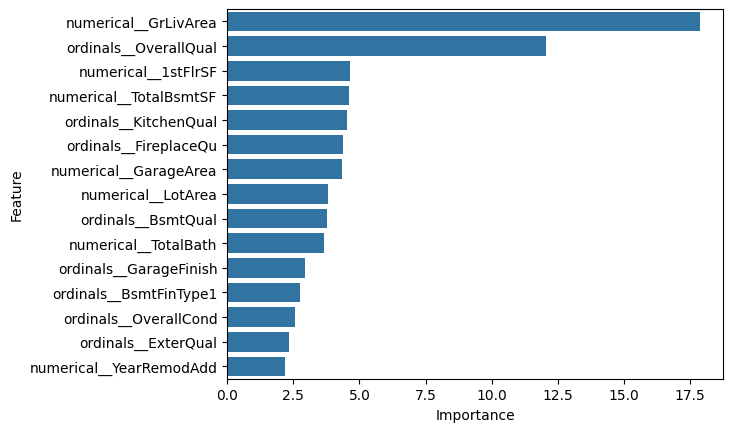

In [195]:
#create final pipeline for the best model
final_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', CatBoostRegressor(
        depth=6,
        learning_rate=0.05,
        iterations=300,
        verbose=0,random_state=42
    ))
])
#feature importance 
final_pipeline.fit(X_train_tree, y_train_tree_log)
        
#i extracted the feature names from the preprocessor , because inside it i did one hot encoding for categorical feautures , which 
#are not included in the original dataset
all_features = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

catboost_model = final_pipeline.named_steps['model']
feature_importances = catboost_model.get_feature_importance()

# --- 5️⃣ Create a DataFrame for plotting ---
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)


top_features = feature_importance_df[:15]
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
)
#from what i noticed is that numerical and ordinal features ar the most important here , while one hot encoded features didnt contrinute at all 
# some importances for one hot encoded features are zero 

8-Finally , Apply the final pipeline to predict The target variable in the testing dataset.

In [196]:
y_test_pred_log = final_pipeline.predict(test_df)
y_test_pred = np.expm1(y_test_pred_log)

print(y_test_pred)  

[126613.20918108 160545.15104589 183149.60870351 ... 156858.81201711
 118587.08747941 212821.81349905]


# 8-Submission File (For kaggle)

In [197]:
submission = pd.DataFrame({
    "Id": test_df.index,     # or the index if no Id column
    "SalePrice": y_test_pred
})

submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

Submission file saved!
